<a href="https://colab.research.google.com/github/william-ckm/A-Permanent-Electromagnet-MR-Fluid-Brake-for-Roller-Coasters-Falcon-s-Flight-Feasibility-Study/blob/main/Magnetorheological_Fluids_Hybrid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# PHASE 1: Problem Definition & Inputs
# ====================================

import numpy as np

# STEP 1.1: Define Roller Coaster Train Parameters
# =================================================

# Train parameters (based on Hyperspace Mountain)
m = 10000          # Mass of train (kg)
v = 20             # Maximum speed (m/s) [72 km/h]
R_wheel = 0.10     # Radius of train wheel (m)
s = 30             # Stopping distance (m)

print("=== ROLLER COASTER PARAMETERS ===")
print(f"Train mass (m)          = {m} kg")
print(f"Maximum speed (v)       = {v} m/s  ({v*3.6:.0f} km/h)")
print(f"Wheel radius (R_wheel)  = {R_wheel} m")
print(f"Stopping distance (s)   = {s} m")

# STEP 1.2: Calculate Design Braking Torque
# =========================================

# Calculate angular displacement of wheel during braking
theta_stop = s / R_wheel  # radians

# Calculate required braking torque
T_design = (0.5 * m * v**2) / theta_stop

print("\n=== DESIGN BRAKING TORQUE ===")
print(f"Angular displacement (θ_stop) = {theta_stop:.2f} radians")
print(f"Required braking torque (T_design) = {T_design:,.0f} Nm")

=== ROLLER COASTER PARAMETERS ===
Train mass (m)          = 10000 kg
Maximum speed (v)       = 20 m/s  (72 km/h)
Wheel radius (R_wheel)  = 0.1 m
Stopping distance (s)   = 30 m

=== DESIGN BRAKING TORQUE ===
Angular displacement (θ_stop) = 300.00 radians
Required braking torque (T_design) = 6,667 Nm


PHASE 2: BRAKE GEOMETRY & FLUID PROPERTIES (HYBRID PM + EM)

=== BRAKE GEOMETRY ===
Inner radius (r_i)          = 0.05 m
Outer radius (r_o)          = 0.15 m
Gap thickness (d)           = 0.005 m  (5.0 mm)
Rotor thickness (t_disc)    = 0.005 m  (5.0 mm)
Number of spinning discs    = 120
Number of fluid gaps (n)    = 240 (2 per disc)

Disc face area (one side)   = 0.0628 m²
Total shear area (all gaps) = 15.0796 m²

=== MR FLUID PROPERTIES (MRF-132DG) ===
Plastic viscosity (mu)       = 0.112 Pa·s (at 40°C)
Density (rho)                = 3000 kg/m³
Specific heat capacity (Cp)  = 800 J/(kg·K)
Saturation yield stress      = 50.0 kPa (manufacturer's value)

=== HYBRID MAGNETIC CIRCUIT ===
Permanent magnets per side   = 1
Total permanent magnets      = 2
Field per PM (B_PM_per_side) = 0.400 T
Total PM field (B_PM_total)  = 0.800 T
Electromagnets per side      = 1
Total electromagnets         = 2
Turns per coil (N)           = 100
Total turns (both coils)     = 200
Relative permeability (mu_r)

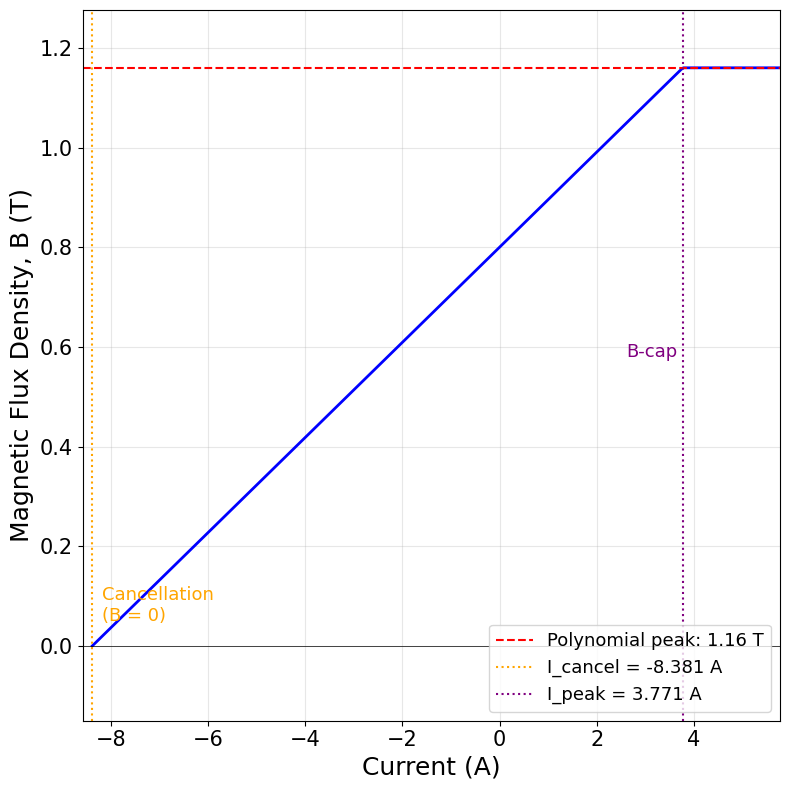

✓ Saved: OUTPUT/phase2_yield_vs_current.png


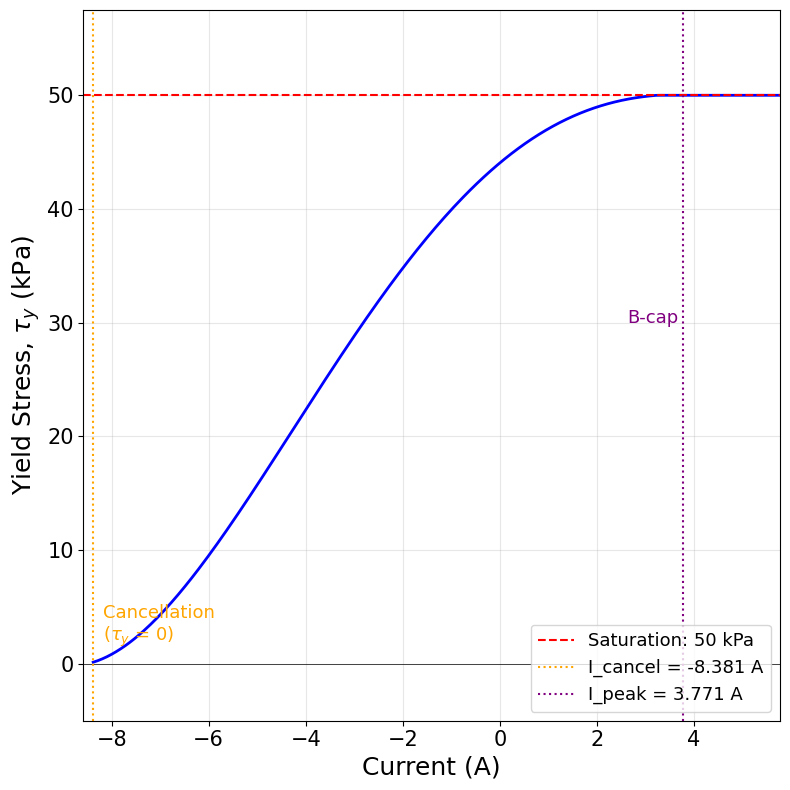

In [ ]:
# PHASE 2: Brake Geometry & Fluid Properties (HYBRID PM + EM)
# ============================================================
# 2 Permanent Magnets (one on each side) + 2 Electromagnets (one on each side)
# 2 MR Fluid Gaps (one on each side of the disc)
# 1 Spinning Disc (in the middle)
#
# Per-disc unit: PM 1 + EM coil 1 (left stator), PM 2 + EM coil 2 (right stator)
# The two PMs and two EM coils are in series along the flux path.
# The two gaps contribute 2d of gap length, so the 2s cancel in the
# derivation and B_EM = mu_0 * mu_r_MR * N * I / d (no extra factor of 2).
#
# NOTE ON mu_r_MR:
# The relative permeability of MRF-132DG is field-dependent. The value
# used here, 3.798, is from the 2024 MDPI Designs paper "Electromagnetic
# Interaction Model between an Electric Motor and a Magnetorheological
# Brake" (DOI: 10.3390/designs8020025). Published values for this fluid
# range from approximately 2.78 to 5.0 depending on field strength and
# measurement method. The choice of 3.798 is a representative value
# within that range.
#
# NOTE ON THE 1.16 T CAP:
# The Parlak et al. (2012) polynomial has a local maximum at
# B = 1.16 T. Below this, yield stress increases monotonically with
# field. Above this, the polynomial becomes non-monotonic: it dips,
# then rises again as the B^4 term dominates. Neither the dip nor the
# subsequent rise is physical; the true yield stress plateaus at the
# fluid's saturation value. The model therefore caps the field at the
# polynomial's peak, 1.16 T.
#
# NOTE ON THE 50 kPa CLAMP:
# The manufacturer quotes the saturation yield stress of MRF-132DG at
# approximately 50 kPa. The polynomial reaches ~50.1 kPa at 1.16 T,
# which is consistent. The yield stress is additionally clamped at
# 50 kPa to prevent the polynomial from ever exceeding the fluid's
# measured saturation value.

import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# STEP 2.1: Define Brake Geometry
# =============================================================================

# Brake geometry parameters
r_i = 0.05          # Inner radius of disc (m)
r_o = 0.15          # Outer radius of disc (m)
d = 0.005           # Gap between disc and stator (m) [5 mm]
t_disc = 0.005      # Rotor disc thickness (m) [5 mm]
m_discs = 120       # Number of spinning discs (one per brake unit)
n = 2 * m_discs     # Number of active fluid gaps (2 per disc)

print("=" * 70)
print("PHASE 2: BRAKE GEOMETRY & FLUID PROPERTIES (HYBRID PM + EM)")
print("=" * 70)

print("\n=== BRAKE GEOMETRY ===")
print(f"Inner radius (r_i)          = {r_i} m")
print(f"Outer radius (r_o)          = {r_o} m")
print(f"Gap thickness (d)           = {d} m  ({d*1000:.1f} mm)")
print(f"Rotor thickness (t_disc)    = {t_disc} m  ({t_disc*1000:.1f} mm)")
print(f"Number of spinning discs    = {m_discs}")
print(f"Number of fluid gaps (n)    = {n} (2 per disc)")
print()
print(f"Disc face area (one side)   = {np.pi*(r_o**2 - r_i**2):.4f} m²")
print(f"Total shear area (all gaps) = {n * np.pi*(r_o**2 - r_i**2):.4f} m²")

# =============================================================================
# STEP 2.2: Define MR Fluid Properties
# =============================================================================

# MR fluid properties (Lord Corporation MRF-132DG)
mu = 0.112           # Plastic viscosity (Pa·s) at 40°C
rho = 3000           # Density (kg/m³)
Cp = 800             # Specific heat capacity (J/(kg·K))
tau_y_max = 50.0     # Saturation yield stress (kPa), manufacturer's value

print("\n=== MR FLUID PROPERTIES (MRF-132DG) ===")
print(f"Plastic viscosity (mu)       = {mu} Pa·s (at 40°C)")
print(f"Density (rho)                = {rho} kg/m³")
print(f"Specific heat capacity (Cp)  = {Cp} J/(kg·K)")
print(f"Saturation yield stress      = {tau_y_max:.1f} kPa (manufacturer's value)")

# =============================================================================
# STEP 2.3: Hybrid Magnetic Field Model (2 PMs + 2 EMs)
# =============================================================================

# Coil and magnetic circuit parameters
N_turns = 100          # Number of turns per coil
mu_0 = 4 * np.pi * 1e-7  # Permeability of free space (H/m)
mu_r_MR = 3.798        # Relative permeability of MR fluid (MDPI Designs 2024)

# Permanent magnet parameters (NdFeB N42)
# One PM per side, two PMs total, oriented to add around the flux loop
B_PM_per_side = 0.4             # Field contributed by one PM to the gap (T)
B_PM_total = 2 * B_PM_per_side  # Total PM bias field in the gap (T)

# Peak of the Parlak et al. (2012) polynomial, i.e. the highest field
# at which the polynomial is still monotonically increasing.
# Above this, the polynomial dips (unphysical) before rising again.
B_sat = 1.16           # T

print("\n=== HYBRID MAGNETIC CIRCUIT ===")
print(f"Permanent magnets per side   = 1")
print(f"Total permanent magnets      = 2")
print(f"Field per PM (B_PM_per_side) = {B_PM_per_side:.3f} T")
print(f"Total PM field (B_PM_total)  = {B_PM_total:.3f} T")
print(f"Electromagnets per side      = 1")
print(f"Total electromagnets         = 2")
print(f"Turns per coil (N)           = {N_turns}")
print(f"Total turns (both coils)     = {2 * N_turns}")
print(f"Relative permeability (mu_r) = {mu_r_MR:.3f}")
print(f"Cap (polynomial peak)        = {B_sat:.2f} T")
print(f"Gap thickness (d)            = {d:.3f} m ({d*1000:.1f} mm)")

def calculate_B(I):
    """
    Total magnetic flux density in the gap (HYBRID 2 PM + 2 EM).

    B_total = B_PM_total + B_EM_total

    The magnetic circuit has two coils (total MMF 2 N I) and two MR gaps
    (total gap length 2 d). Ampere's law around the loop gives:

        2 N I = 2 H_gap d

    so H_gap = N I / d and B_EM = mu_0 * mu_r_MR * N * I / d.
    The two 2s cancel.

    The field is capped at B_sat = 1.16 T, the peak of the Parlak
    polynomial. Above this, the polynomial is non-monotonic.

    Parameters:
    I : Coil current (A) [positive = add to PM, negative = subtract]

    Returns:
    B_total : Total flux density in the gap (T), capped at the
              polynomial peak
    """
    B_EM_total = (mu_0 * mu_r_MR * N_turns * I) / d
    B_total = B_PM_total + B_EM_total
    return max(min(B_total, B_sat), -B_sat)

def yield_stress_from_B(B):
    """
    Yield stress from magnetic flux density (Parlak et al., 2012).

    tau_y(B) = 52.962B^4 - 176.51B^3 + 158.79B^2 + 13.708B + 0.1442
    tau_y in kPa, B in Tesla.

    WARNING: The polynomial has a local maximum at B = 1.16 T.
    Above this it dips and then rises again, neither of which is
    physical. The model caps B at 1.16 T to avoid this region.

    The result is additionally clamped at the manufacturer's
    saturation yield stress of 50 kPa, so the model never predicts
    a yield stress higher than the fluid can actually produce.

    For negative B (reverse current), we use absolute value since
    yield stress is always positive.
    """
    B_abs = abs(B)
    tau_y_kPa = 52.962 * B_abs**4 - 176.51 * B_abs**3 + 158.79 * B_abs**2 + 13.708 * B_abs + 0.1442
    # Clamp at the manufacturer's saturation value
    tau_y_kPa = min(tau_y_kPa, tau_y_max)
    return tau_y_kPa * 1000  # Convert to Pa

def tau_y_from_I(I):
    """Complete chain: Current -> B -> Yield Stress."""
    B = calculate_B(I)
    return yield_stress_from_B(B)

# =============================================================================
# STEP 2.4: Operating Modes and Current Range
# =============================================================================

print("\n=== OPERATING MODES (2 PMs + 2 EMs) ===")
print("Current (A) | B_total (T) | tau_y (kPa) | Mode")
print("------------|--------------|-------------|------------------")

# Cancellation current: B_total = 0
I_cancel = -B_PM_total * d / (mu_0 * mu_r_MR * N_turns)

# Current at which B_total reaches the polynomial peak
I_sat = (B_sat - B_PM_total) * d / (mu_0 * mu_r_MR * N_turns)

for I in [-1.0, -0.6, I_cancel, -0.2, 0.0, 0.5, 1.0, I_sat, 8.0]:
    B = calculate_B(I)
    tau_y = tau_y_from_I(I) / 1000  # Convert to kPa
    if abs(I - I_cancel) < 1e-6:
        mode = "FULL RELEASE"
    elif abs(I - I_sat) < 1e-6:
        mode = "POLY. PEAK / SAT."
    elif I < -0.3:
        mode = "Cancellation (weak)"
    elif I < 0:
        mode = "Partial release"
    elif I == 0:
        mode = "FAIL-SAFE (PM only)"
    else:
        mode = "Enhancement (strong)"
    print(f"{I:>10.3f} | {B:>12.3f} | {tau_y:>11.1f} | {mode}")

print(f"\nCancellation current (I_cancel)   = {I_cancel:.4f} A")
print(f"Polynomial peak current (I_sat)   = {I_sat:.4f} A")
print(f"At I_cancel, B_total = 0 T, tau_y = 0 Pa (brake fully released)")

# =============================================================================
# STEP 2.5: Plot B and Yield Stress vs Current (SEPARATE SQUARE FIGURES, 800 DPI)
# =============================================================================

import os
from pathlib import Path

# Create output folder if it doesn't exist
OUTPUT_DIR = Path("OUTPUT")
OUTPUT_DIR.mkdir(exist_ok=True)

# Plot the right branch only: from I_cancel (zero field) up to a current
# well past the polynomial peak. The full physical range is
# [I_cancel, I_sat], but we extend the upper limit to show the plateau.

I_min_plot = I_cancel                    # cancellation current (B = 0)
I_max_plot = I_sat + 2.0                 # well past the peak

I_range = np.linspace(I_min_plot, I_max_plot, 300)
B_range = [calculate_B(I) for I in I_range]
tau_y_range = [tau_y_from_I(I) / 1000 for I in I_range]  # kPa

# Square dimensions for both figures
FIG_SIZE = (8, 8)

# -------------------------------------------------------------------------
# Figure 2a: B vs Current (square)
# -------------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=FIG_SIZE)

ax1.plot(I_range, B_range, 'b-', linewidth=2)
ax1.axhline(y=0.0, color='k', linestyle='-', linewidth=0.5)
ax1.axhline(y=B_sat, color='r', linestyle='--',
            label=f'Polynomial peak: {B_sat:.2f} T')
ax1.axhline(y=-B_sat, color='r', linestyle='--')
ax1.axvline(x=I_cancel, color='orange', linestyle=':', label=f'I_cancel = {I_cancel:.3f} A')
ax1.axvline(x=I_sat, color='purple', linestyle=':', label=f'I_peak = {I_sat:.3f} A')
ax1.set_xlabel('Current (A)', fontsize=18)
ax1.set_ylabel('Magnetic Flux Density, B (T)', fontsize=18)
ax1.set_xlim(I_min_plot - 0.2, I_max_plot)
ax1.set_ylim(-0.15, B_sat * 1.1)
ax1.tick_params(axis='both', labelsize=15)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='lower right', fontsize=13)

# Cancellation text (to the right of the orange line, inside the grid)
ax1.text(I_cancel + 0.2, 0.05, 'Cancellation\n(B = 0)', fontsize=13, color='orange')

# B-cap text — moved to the LEFT of the purple line
ax1.text(I_sat - 0.1, 0.5 * B_sat, 'B-cap',
         fontsize=13, color='purple', ha='right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase2_B_vs_current.png", dpi=800, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_DIR / 'phase2_B_vs_current.png'}")
plt.show()

# -------------------------------------------------------------------------
# Figure 2b: Yield Stress vs Current (square)
# -------------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=FIG_SIZE)

ax2.plot(I_range, tau_y_range, 'b-', linewidth=2)
ax2.axhline(y=0.0, color='k', linestyle='-', linewidth=0.5)
ax2.axhline(y=tau_y_max, color='r', linestyle='--',
            label=f'Saturation: {tau_y_max:.0f} kPa')
ax2.axvline(x=I_cancel, color='orange', linestyle=':', label=f'I_cancel = {I_cancel:.3f} A')
ax2.axvline(x=I_sat, color='purple', linestyle=':', label=f'I_peak = {I_sat:.3f} A')
ax2.set_xlabel('Current (A)', fontsize=18)
ax2.set_ylabel(r'Yield Stress, $\tau_y$ (kPa)', fontsize=18)
ax2.set_xlim(I_min_plot - 0.2, I_max_plot)
ax2.set_ylim(-5, tau_y_max * 1.15)
ax2.tick_params(axis='both', labelsize=15)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='lower right', fontsize=13)

# Cancellation text (to the right of the orange line, inside the grid)
ax2.text(I_cancel + 0.2, 2, r'Cancellation' + '\n' + r'($\tau_y$ = 0)',
         fontsize=13, color='orange')

# B-cap text — moved to the LEFT of the purple line
ax2.text(I_sat - 0.1, 0.6 * tau_y_max, 'B-cap',
         fontsize=13, color='purple', ha='right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase2_yield_vs_current.png", dpi=800, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_DIR / 'phase2_yield_vs_current.png'}")
plt.show()

PHASE 3: PHYSICS MODEL (The MATH Engine)

--- DESIGN TORQUE (from Phase 1) ---
T_design = 6,667 Nm

--- CANCELLATION CURRENT ---
mu_r_MR = 3.798
I_cancel = -8.3810 A (zero field in the gap)

=== TORQUE CHECK ===
Current (A) | B_total (T) | tau_y (kPa) | T_on (Nm) | T_off (Nm) | T_total (Nm)
------------|--------------|-------------|-----------|------------|-------------
      -1.0 |        0.705 |        39.9 |     65251 |        844 |       66096
      -0.5 |        0.752 |        42.1 |     68833 |        844 |       69678
       0.0 |        0.800 |        44.1 |     71972 |        844 |       72816
       0.5 |        0.848 |        45.7 |     74653 |        844 |       75498
       1.0 |        0.895 |        47.1 |     76877 |        844 |       77721
       2.0 |        0.991 |        49.0 |     79992 |        844 |       80837

✓ Saved: OUTPUT/phase3_torque_vs_speed.png


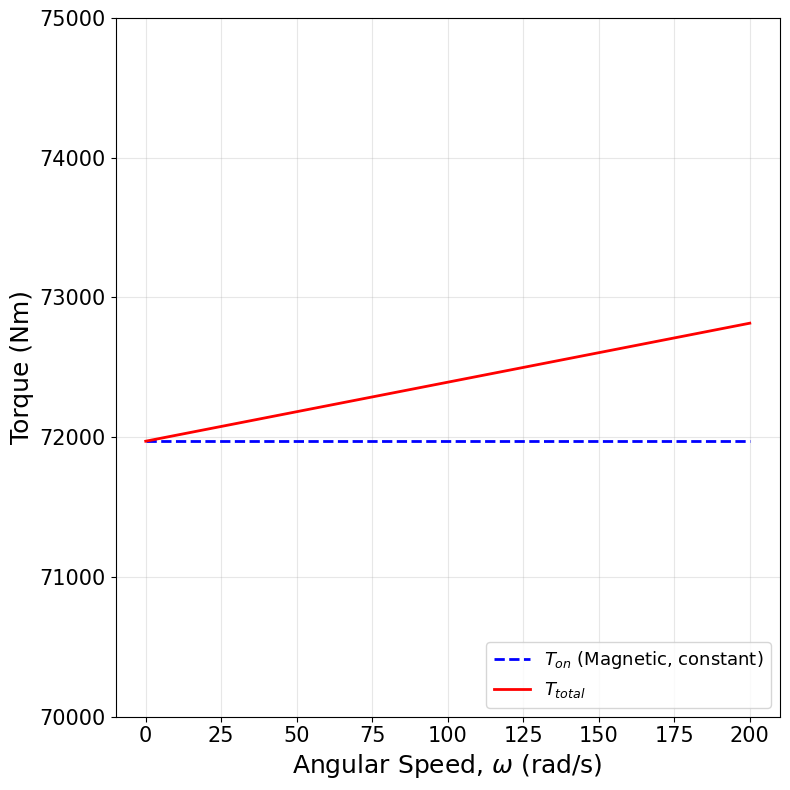

✓ Saved: OUTPUT/phase3_torque_vs_current.png


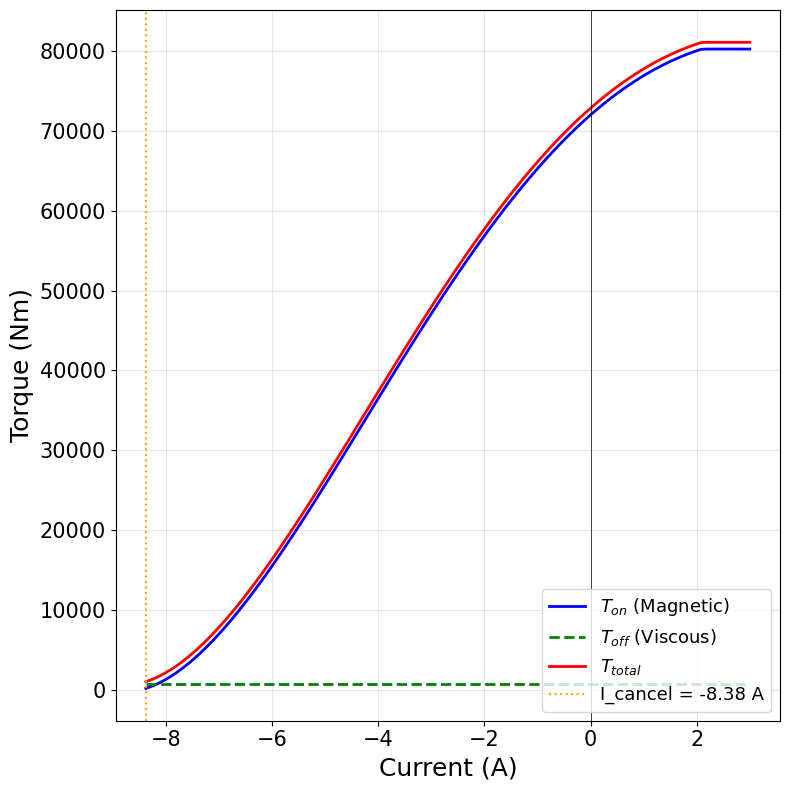

In [ ]:
"""
PHASE 3: Physics Model (The MATH Engine)
MR Fluid Brake Feasibility Study - HYBRID PM + EM

Torque conventions (n = number of fluid gaps = 2 * m_discs):
  T_on  = (2 pi n / 3) tau_y (r_o^3 - r_i^3)
  T_off = (pi n mu omega / (2 d)) (r_o^4 - r_i^4)
Both expressions use n = number of gaps, consistently.

Relative permeability of MRF-132DG: 3.798 (MDPI Designs 2024,
DOI 10.3390/designs8020025). Published values range from ~2.78 to 5.0
depending on field strength and measurement method.
"""

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D projection)

# =============================================================================
# STEP 3.1: Define All Constants
# =============================================================================

# --- Train parameters (from Phase 1) ---
m = 10000            # Train mass (kg)
v = 20               # Maximum speed (m/s)
R_wheel = 0.10       # Wheel radius (m)
s = 30               # Stopping distance (m)

# --- Brake geometry (from Phase 2) ---
r_i = 0.05           # Inner radius (m)
r_o = 0.15           # Outer radius (m)
d = 0.005            # Gap thickness (m) [5 mm]
t_disc = 0.005       # Rotor thickness (m) [5 mm]
m_discs = 120        # Number of spinning discs
n = 2 * m_discs      # Number of active fluid gaps (2 per disc)

# --- MR fluid properties (from Phase 2) ---
mu = 0.112           # Plastic viscosity (Pa·s at 40°C)
rho = 3000           # Density (kg/m³)
Cp = 800             # Specific heat (J/(kg·K))

# --- Magnetic circuit (from Phase 2) ---
B_PM_per_side = 0.4
B_PM_total = 2 * B_PM_per_side
N_turns = 100
mu_0 = 4 * np.pi * 1e-7
mu_r_MR = 3.798      # Relative permeability of MRF-132DG (MDPI Designs 2024)
B_sat = 1.0

# Cancellation current: the current that zeroes the field in the gap
I_cancel = -B_PM_total * d / (mu_0 * mu_r_MR * N_turns)

# =============================================================================
# STEP 3.2: Define Physics Functions (from Phase 2)
# =============================================================================

def calculate_B(I):
    """
    Total magnetic flux density (2 PMs + 2 EMs).

    Two coils give total MMF 2 N I; two gaps consume total MMF 2 H d.
    The 2s cancel, leaving B_EM = mu_0 * mu_r_MR * N * I / d.
    """
    B_EM_total = (mu_0 * mu_r_MR * N_turns * I) / d
    B_total = B_PM_total + B_EM_total
    return max(min(B_total, B_sat), -B_sat)

def yield_stress_from_B(B):
    """Yield stress from magnetic flux density (Parlak et al., 2012)."""
    B_abs = abs(B)
    tau_y_kPa = 52.962 * B_abs**4 - 176.51 * B_abs**3 + 158.79 * B_abs**2 + 13.708 * B_abs + 0.1442
    return tau_y_kPa * 1000  # Convert to Pa

def tau_y_from_I(I):
    """Complete chain: Current -> B -> Yield Stress."""
    B = calculate_B(I)
    return yield_stress_from_B(B)

# =============================================================================
# STEP 3.3: Define Torque Functions
# =============================================================================

def T_on(I):
    """
    On-state torque (magnetic braking).

    Equation: T_on = (2 pi n tau_y / 3) * (r_o^3 - r_i^3)

    Derivation: Integration of yield stress over one fluid gap gives
    (2 pi / 3) tau_y (r_o^3 - r_i^3). Multiplying by n gaps gives the
    total. The factor of 2 pi (not 4 pi) reflects that each gap is a
    single fluid layer; the 4 pi form would apply only if n counted discs
    rather than gaps.
    """
    tau_y = tau_y_from_I(I)
    return (2 * np.pi * n * tau_y / 3) * (r_o**3 - r_i**3)

def T_off(omega):
    """
    Off-state torque (viscous drag).

    Equation: T_off = (pi n mu omega / (2 d)) * (r_o^4 - r_i^4)

    Derivation: Integration of viscous shear stress over one fluid gap
    gives (pi mu omega / (2 d)) (r_o^4 - r_i^4). Multiplying by n gaps
    gives the total. Consistent with the n = gaps convention.
    """
    return (np.pi * n * mu * omega / (2 * d)) * (r_o**4 - r_i**4)

def T_total(I, omega):
    """
    Total braking torque.

    Equation: T_total = T_on + T_off

    Valid because the Bingham model is linear:
        tau_total = tau_y(B) + mu * gamma_dot
    """
    return T_on(I) + T_off(omega)

# =============================================================================
# STEP 3.4: Calculate Design Torque (from Phase 1)
# =============================================================================

theta_stop = s / R_wheel
T_design = (0.5 * m * v**2) / theta_stop

print("=" * 70)
print("PHASE 3: PHYSICS MODEL (The MATH Engine)")
print("=" * 70)

print(f"\n--- DESIGN TORQUE (from Phase 1) ---")
print(f"T_design = {T_design:,.0f} Nm")

print(f"\n--- CANCELLATION CURRENT ---")
print(f"mu_r_MR = {mu_r_MR:.3f}")
print(f"I_cancel = {I_cancel:.4f} A (zero field in the gap)")

# =============================================================================
# STEP 3.5: Debug Check
# =============================================================================

print("\n=== TORQUE CHECK ===")
print("Current (A) | B_total (T) | tau_y (kPa) | T_on (Nm) | T_off (Nm) | T_total (Nm)")
print("------------|--------------|-------------|-----------|------------|-------------")

omega_test = v / R_wheel  # Maximum angular speed

for I in [-1.0, -0.5, 0.0, 0.5, 1.0, 2.0]:
    B = calculate_B(I)
    tau_y = tau_y_from_I(I) / 1000  # kPa
    T_on_val = T_on(I)
    T_off_val = T_off(omega_test)
    T_total_val = T_total(I, omega_test)
    print(f"{I:>10.1f} | {B:>12.3f} | {tau_y:>11.1f} | {T_on_val:>9.0f} | {T_off_val:>10.0f} | {T_total_val:>11.0f}")

print("\n" + "=" * 70)

# =============================================================================
# STEP 3.6: Plots (SEPARATE FILES, 800 DPI, NO TITLES)
# =============================================================================

from pathlib import Path

OUTPUT_DIR = Path("OUTPUT")
OUTPUT_DIR.mkdir(exist_ok=True)

# Plot data
I_range = np.linspace(I_cancel, 3.0, 100)
T_on_range = [T_on(I) for I in I_range]
T_off_range = [T_off(omega_test) for _ in I_range]
T_total_range = [T_total(I, omega_test) for I in I_range]

omega_range = np.linspace(0, 200, 100)
I_test = 0.0
T_on_vs_speed = [T_on(I_test) for _ in omega_range]
T_total_vs_speed = [T_on(I_test) + T_off(omega) for omega in omega_range]

FIG_SIZE = (8, 8)

# -------------------------------------------------------------------------
# Figure 3a: Torque vs Speed
# -------------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=FIG_SIZE)

ax1.plot(omega_range, T_on_vs_speed, 'b--', linewidth=2, label=r'$T_{on}$ (Magnetic, constant)')
ax1.plot(omega_range, T_total_vs_speed, 'r-', linewidth=2, label=r'$T_{total}$')
ax1.set_xlabel(r'Angular Speed, $\omega$ (rad/s)', fontsize=18)
ax1.set_ylabel('Torque (Nm)', fontsize=18)
ax1.set_ylim(70000, 75000)
ax1.tick_params(axis='both', labelsize=15)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='lower right', fontsize=13)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase3_torque_vs_speed.png", dpi=800, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_DIR / 'phase3_torque_vs_speed.png'}")
plt.show()

# -------------------------------------------------------------------------
# Figure 3b: Torque vs Current
# -------------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=FIG_SIZE)

ax2.plot(I_range, T_on_range, 'b-', linewidth=2, label=r'$T_{on}$ (Magnetic)')
ax2.plot(I_range, T_off_range, 'g--', linewidth=2, label=r'$T_{off}$ (Viscous)')
ax2.plot(I_range, T_total_range, 'r-', linewidth=2, label=r'$T_{total}$')
ax2.axvline(x=I_cancel, color='orange', linestyle=':', label=f'I_cancel = {I_cancel:.2f} A')
ax2.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Current (A)', fontsize=18)
ax2.set_ylabel('Torque (Nm)', fontsize=18)
ax2.tick_params(axis='both', labelsize=15)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='lower right', fontsize=13)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase3_torque_vs_current.png", dpi=800, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_DIR / 'phase3_torque_vs_current.png'}")
plt.show()

FINDING CURRENT FOR TARGET DECELERATION
Target deceleration: 4.905 m/s² (0.5g)
Required torque: 4905 Nm

mu_r_MR = 3.798
Cancellation current (I_cancel) = -8.380987 A
   (At I_cancel, B_total = 0 -> zero magnetic braking torque)
Deceleration at I_cancel: 1.0800 m/s² (should be small, viscous only)

--- FINDING BRACKET ---
  I = -7.380987 A -> decel = 5.3376 m/s²
  Bracket found: I in [-8.380987, -7.380987] A

--- BINARY SEARCH ---
  Iter 1: I = -7.880987 A -> decel = 2.7088 m/s²
  Iter 6: I = -7.459112 A -> decel = 4.8680 m/s²
  Iter 11: I = -7.452764 A -> decel = 4.9054 m/s²
  Iter 16: I = -7.452841 A -> decel = 4.9049 m/s²
  Iter 21: I = -7.452828 A -> decel = 4.9050 m/s²
  Iter 22: I = -7.452828 A -> decel = 4.9050 m/s²
  Iter 25: I = -7.452828 A -> decel = 4.9050 m/s²
  Iter 26: I = -7.452828 A -> decel = 4.9050 m/s²
  Iter 27: I = -7.452828 A -> decel = 4.9050 m/s²
  Iter 28: I = -7.452828 A -> decel = 4.9050 m/s²
  Iter 29: I = -7.452828 A -> decel = 4.9050 m/s²
  Iter 30: I = -7

/tmp/ipykernel_2227/3541616448.py:399: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  distance_stopped = np.trapz(speed_array, time_array) if len(time_array) > 1 else 0
/tmp/ipykernel_2227/3541616448.py:402: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_elec_brake = np.trapz(P_elec_array, time_array) if len(time_array) > 1 else 0


✓ Saved: OUTPUT/phase4_omega_vs_time.png


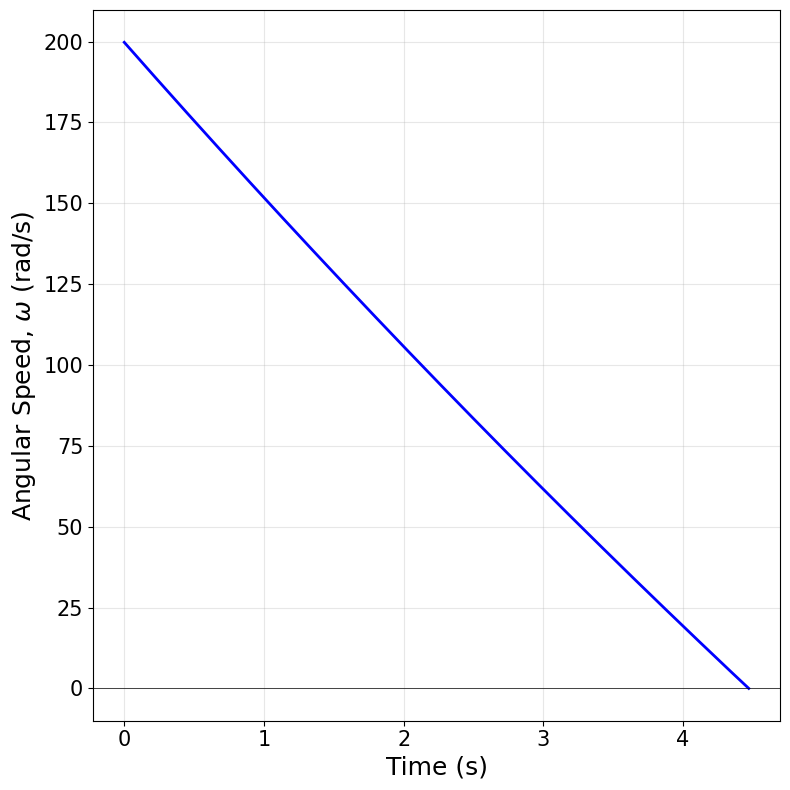

✓ Saved: OUTPUT/phase4_temperature_vs_time.png


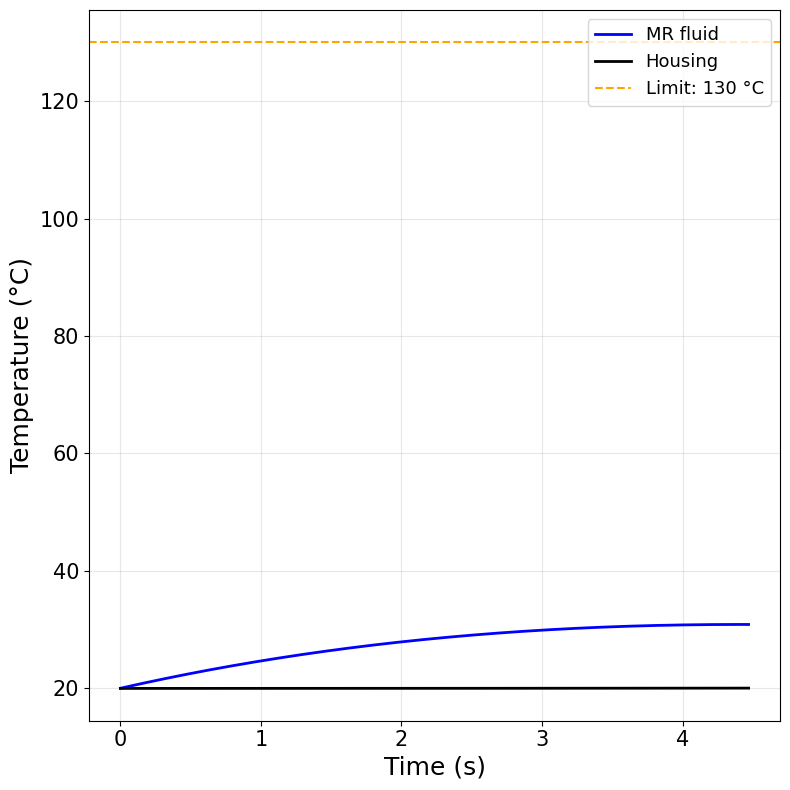

✓ Saved: OUTPUT/phase4_torque_vs_time.png


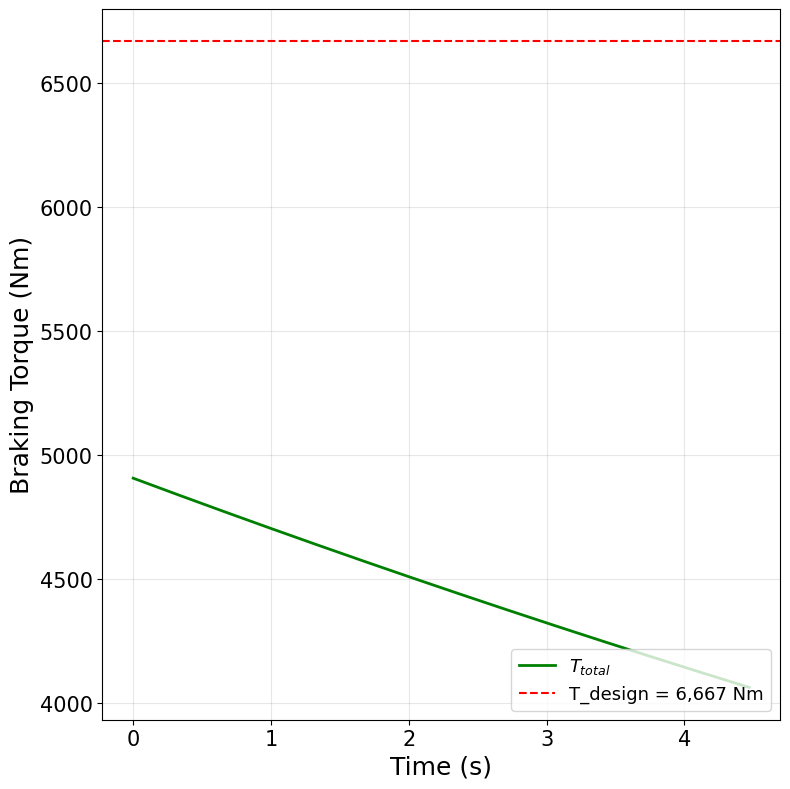

✓ Saved: OUTPUT/phase4_elec_power_vs_time.png


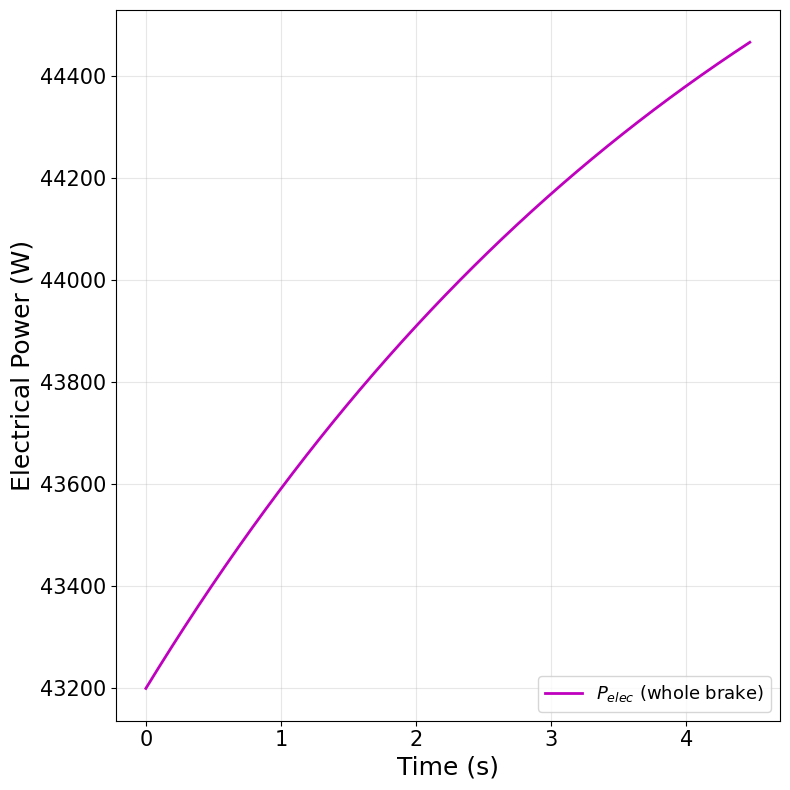


PHASE 4 COMPLETE


In [ ]:
"""
PHASE 4: System Dynamics & Thermal Model (HYBRID PM + EM)
MR Fluid Brake Feasibility Study - Hyperspace Mountain
TARGET DECELERATION: 0.5g
Starting from I_cancel (zero braking), search positive direction.

Torque convention (n = number of fluid gaps = 2 * m_discs):
  T_on  = (2 pi n / 3) tau_y (r_o^3 - r_i^3)
  T_off = (pi n mu omega / (2 d)) (r_o^4 - r_i^4)
Both expressions use n = number of gaps, consistently.

THERMAL MODEL (THREE-NODE, PER UNIT):
  All thermal ODEs are PER UNIT (one disc, two coils, two MR gaps).
  P_fluid_unit = P_fluid_total / m_discs
  P_elec_unit  = P_elec_total / m_discs
  m_fluid_unit = 2 * pi * (r_o^2 - r_i^2) * d * rho
  m_coil       = per unit (two coils in series)
  m_housing    = per unit (hollow steel cylinder)

Relative permeability of MRF-132DG: 3.798 (MDPI Designs 2024,
DOI 10.3390/designs8020025). Published values range from ~2.78 to 5.0
depending on field strength and measurement method.
"""

import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# STEP 1: Define All Parameters
# =============================================================================

# Train parameters
m = 10000            # kg
v = 20               # m/s
R_wheel = 0.10       # m
s = 30               # Stopping distance (m)

# Brake geometry (Phase 2)
r_i = 0.05           # m
r_o = 0.15           # m
d = 0.005            # m [5 mm]
t_disc = 0.005       # m [5 mm]
m_discs = 120        # Number of spinning discs (matches Phases 2 and 3)
n = 2 * m_discs      # Total number of gaps

# MR fluid properties (Phase 2)
mu = 0.112           # Pa·s
rho = 3000           # kg/m³
Cp = 800             # J/(kg·K)

# Magnetic circuit (Phase 2)
N_turns = 100
mu_0 = 4 * np.pi * 1e-7
mu_r_MR = 3.798      # Relative permeability of MRF-132DG (MDPI Designs 2024)
B_PM_per_side = 0.4
B_PM_total = 2 * B_PM_per_side
B_sat = 1.0

# Coil parameters (for electrical energy calculation)
r_mean_coil = 0.10          # m
wire_diameter = 0.644e-3    # m (AWG 22)
wire_area = np.pi * (wire_diameter / 2)**2
rho_copper_20C = 1.68e-8    # ohm·m at 20 °C
alpha_copper = 0.00393      # per °C
n_coils_per_unit = 2
l_wire_one_coil = 2 * np.pi * r_mean_coil * N_turns

# Resistance of one unit (two coils in series)
R_unit_20C = n_coils_per_unit * rho_copper_20C * l_wire_one_coil / wire_area

# Thermal parameters
T_ambient = 20.0     # Ambient temperature (°C)
T_limit_rise = 110.0  # Temperature rise limit (°C)

# Three-node thermal parameters
# Housing: closed steel cylinder, r_out = 0.18 m, L = 0.22 m, wall = 10 mm
rho_steel = 7850.0
r_housing_out = 0.18
r_housing_in = 0.17
L_housing = 0.22
V_tube = np.pi * (r_housing_out**2 - r_housing_in**2) * L_housing
V_caps = 2 * np.pi * (r_housing_out**2 - r_i**2) * (r_housing_out - r_housing_in)
V_housing = V_tube + V_caps
m_housing = rho_steel * V_housing
Cp_steel = 500.0
A_housing = 0.452

# Coil thermal mass (PER UNIT)
rho_copper_density = 8960.0
V_wire_one_unit = n_coils_per_unit * l_wire_one_coil * wire_area
m_coil = rho_copper_density * V_wire_one_unit
Cp_copper = 385.0

# Fluid thermal mass (PER UNIT)
m_fluid_unit = 2 * np.pi * (r_o**2 - r_i**2) * d * rho

# Thermal resistances
h_eff_coil_housing = 300.0          # W/(m^2 K)
A_coil_surface = 0.102              # m^2
R_CH = 1.0 / (h_eff_coil_housing * A_coil_surface)   # K/W

k_F_eff = 0.319                     # W/(m K)
h_gap = k_F_eff / d                 # W/(m^2 K)
A_fluid_surface = 0.126             # m^2
R_FH = 1.0 / (h_gap * A_fluid_surface)   # K/W

# Simulation parameters
dt = 0.005           # Time step (s)
max_time = 60.0      # Maximum simulation time (s)
max_steps = 20000    # Safety limit

# =============================================================================
# STEP 2: Define Physics Functions
# =============================================================================

def calculate_B(I):
    """
    Total magnetic flux density (2 PMs + 2 EMs).

    Two coils give total MMF 2 N I; two gaps consume total MMF 2 H d.
    The 2s cancel, leaving B_EM = mu_0 * mu_r_MR * N * I / d.
    """
    B_EM_total = (mu_0 * mu_r_MR * N_turns * I) / d
    B_total = B_PM_total + B_EM_total
    return max(min(B_total, B_sat), -B_sat)

def yield_stress_from_B(B):
    """Yield stress from magnetic flux density (Parlak et al., 2012)."""
    B_abs = abs(B)
    tau_y_kPa = 52.962 * B_abs**4 - 176.51 * B_abs**3 + 158.79 * B_abs**2 + 13.708 * B_abs + 0.1442
    return tau_y_kPa * 1000  # Convert to Pa

def tau_y_from_I(I):
    """Complete chain: Current -> B -> Yield Stress."""
    B = calculate_B(I)
    return yield_stress_from_B(B)

def T_on(I):
    """
    On-state torque (magnetic braking).

    T_on = (2 pi n tau_y / 3) * (r_o^3 - r_i^3)

    One fluid gap contributes (2 pi / 3) tau_y (r_o^3 - r_i^3).
    Multiplying by n gaps gives the total. The factor is 2 pi, not 4 pi,
    because n already counts gaps (not disc faces).
    """
    tau_y = tau_y_from_I(I)
    return (2 * np.pi * n * tau_y / 3) * (r_o**3 - r_i**3)

def T_off(omega):
    """Off-state torque (viscous drag)."""
    return (np.pi * n * mu * omega / (2 * d)) * (r_o**4 - r_i**4)

def T_total(I, omega):
    """Total braking torque."""
    return T_on(I) + T_off(omega)

def fluid_mass_total():
    """Total mass of MR fluid in the whole brake."""
    return n * np.pi * (r_o**2 - r_i**2) * d * rho

def R_unit(T_coil):
    """Resistance of one unit at coil temperature T_coil (two coils in series)."""
    rho_copper = rho_copper_20C * (1 + alpha_copper * (T_coil - 20.0))
    return n_coils_per_unit * rho_copper * l_wire_one_coil / wire_area

def P_elec_total(I, T_coil):
    """
    Total electrical power for the whole brake (all units in parallel,
    each driven at the same current I).
    """
    return m_discs * I**2 * R_unit(T_coil)

def h_convection(v):
    """Forced-convection coefficient h = 8 v^(3/4) W/(m^2 K), v in m/s."""
    v_abs = max(abs(v), 0.0)
    return 8.0 * (v_abs ** 0.75)

m_fluid_total = fluid_mass_total()

# =============================================================================
# STEP 3: Find Current for Target Deceleration (0.5g)
# =============================================================================

# Target deceleration
target_decel_ms2 = 0.5 * 9.81              # 4.905 m/s²
target_decel_rad = target_decel_ms2 / R_wheel  # rad/s²

# Required torque at the start of braking (omega = v/R_wheel)
omega_start = v / R_wheel
T_required = m * R_wheel**2 * target_decel_rad

print("=" * 70)
print("FINDING CURRENT FOR TARGET DECELERATION")
print("=" * 70)
print(f"Target deceleration: {target_decel_ms2:.3f} m/s² (0.5g)")
print(f"Required torque: {T_required:.0f} Nm")

# Cancellation current (where net field = 0)
I_cancel = -B_PM_total * d / (mu_0 * mu_r_MR * N_turns)
print(f"\nmu_r_MR = {mu_r_MR:.3f}")
print(f"Cancellation current (I_cancel) = {I_cancel:.6f} A")
print(f"   (At I_cancel, B_total = 0 -> zero magnetic braking torque)")

# Check deceleration at I_cancel (should be only viscous drag)
decel_at_cancel = T_total(I_cancel, omega_start) / (m * R_wheel**2)
print(f"Deceleration at I_cancel: {decel_at_cancel * R_wheel:.4f} m/s² (should be small, viscous only)")

def deceleration_error(I):
    """Error between actual and target deceleration at start of braking."""
    T_now = T_total(I, omega_start)
    decel_actual = T_now / (m * R_wheel**2)
    return decel_actual - target_decel_rad

# Binary search: start at I_cancel (zero magnetic braking) and go positive
I_low = I_cancel          # At this current, magnetic braking is ~0
I_high = I_cancel + 1.0   # Small positive step

print("\n--- FINDING BRACKET ---")
decel_high = 0.0
for i in range(30):
    decel_high = deceleration_error(I_high) * R_wheel + target_decel_ms2
    print(f"  I = {I_high:.6f} A -> decel = {decel_high:.4f} m/s²")
    if decel_high >= target_decel_ms2:
        print(f"  Bracket found: I in [{I_low:.6f}, {I_high:.6f}] A")
        break
    I_low = I_high
    I_high = I_cancel + (I_high - I_cancel) * 1.5  # Exponential expansion from I_cancel

if decel_high < target_decel_ms2:
    print("\nWARNING: Deceleration never reached target. Expanding search...")
    while decel_high < target_decel_ms2 and I_high < (I_cancel + 20.0):
        I_low = I_high
        I_high = I_cancel + (I_high - I_cancel) * 1.5
        decel_high = deceleration_error(I_high) * R_wheel + target_decel_ms2
        print(f"  I = {I_high:.6f} A -> decel = {decel_high:.4f} m/s²")

# Binary search
print("\n--- BINARY SEARCH ---")
for i in range(60):
    I_mid = (I_low + I_high) / 2
    err = deceleration_error(I_mid)
    decel_mid = err * R_wheel + target_decel_ms2

    if i % 5 == 0 or abs(err) < 1e-6:
        print(f"  Iter {i+1}: I = {I_mid:.6f} A -> decel = {decel_mid:.4f} m/s²")

    if abs(err) < 1e-8:
        break
    if err > 0:
        I_high = I_mid   # Deceleration too high -> need less current
    else:
        I_low = I_mid    # Deceleration too low -> need more current

I_applied = (I_low + I_high) / 2

print(f"\nCurrent for 0.5g deceleration: {I_applied:.6f} A")
print(f"   T_on    = {T_on(I_applied):.0f} Nm")
print(f"   T_off   = {T_off(omega_start):.0f} Nm")
print(f"   T_total = {T_total(I_applied, omega_start):.0f} Nm")

# Verify deceleration at start
actual_decel = T_total(I_applied, omega_start) / (m * R_wheel**2)
print(f"   Actual deceleration at start: {actual_decel * R_wheel:.4f} m/s²")

# =============================================================================
# STEP 4: Calculate Design Torque (for reference)
# =============================================================================

theta_stop = s / R_wheel
T_design = (0.5 * m * v**2) / theta_stop

print("\n" + "=" * 70)
print("PHASE 4: SYSTEM DYNAMICS & THERMAL MODEL (HYBRID PM + EM)")
print("=" * 70)
print(f"\n--- DESIGN TORQUE ---")
print(f"Required braking torque (T_design) = {T_design:,.0f} Nm")
print(f"Current for 0.5g: {I_applied:.6f} A")

# =============================================================================
# STEP 5: Run the Braking Simulation
# =============================================================================

print(f"\n--- OPERATING MODE ---")
if I_applied > 0:
    print(f"ENHANCEMENT: PM + EM adding (I = {I_applied:.3f} A)")
else:
    print(f"CANCELLATION: PM + EM opposing (I = {I_applied:.3f} A)")

# Initial conditions
omega = v / R_wheel   # Initial angular speed (rad/s)
time = 0
T_fluid = T_ambient
T_housing = T_ambient
T_coil = T_ambient

# Arrays to store results
time_array = []
omega_array = []
T_fluid_array = []
T_housing_array = []
T_array = []
power_array = []
T_on_array = []
T_off_array = []
P_elec_array = []      # electrical power (whole brake) at each step

print(f"\n--- SIMULATION PARAMETERS ---")
print(f"Initial speed: {v} m/s ({v*3.6:.0f} km/h)")
print(f"Initial angular speed: {omega:.1f} rad/s")
print(f"Applied current: {I_applied:.3f} A")
print(f"Fluid mass (per unit): {m_fluid_unit:.4f} kg")
print(f"Fluid mass (total):    {m_fluid_total:.2f} kg")
print(f"Housing mass: {m_housing:.2f} kg")
print(f"Coil mass: {m_coil:.4f} kg")
print(f"Ambient temperature: {T_ambient:.1f} °C")
print(f"Temperature rise limit: {T_limit_rise:.0f} °C")
print(f"Time step: {dt*1000:.1f} ms")

print(f"\n--- RUNNING SIMULATION ---")

step = 0
while omega > 0.001 and time < max_time and step < max_steps:
    step += 1

    if step % 2000 == 0:
        print(f"  Step {step}: time={time:.2f}s, omega={omega:.1f} rad/s")

    T_now = T_total(I_applied, omega)
    T_on_now = T_on(I_applied)
    T_off_now = T_off(omega)

    # Electrical power for the whole brake at this instant.
    P_elec_now = P_elec_total(I_applied, T_coil)

    alpha = T_now / (m * R_wheel**2)

    # --- Three-node thermal update (PER UNIT) ---
    v_now = omega * R_wheel
    h_now = h_convection(v_now)

    # Per-unit heat generation
    P_fluid_unit = (T_on_now + T_off_now) * omega / m_discs
    P_elec_unit = P_elec_now / m_discs

    # Conduction and convection heat flows (per unit)
    P_cond_CH_unit = (T_coil - T_housing) / R_CH
    P_cond_FH_unit = (T_fluid - T_housing) / R_FH
    P_conv_H_unit = h_now * A_housing * (T_housing - T_ambient)

    # Coil ODE (per unit)
    dT_coil = (P_elec_unit - P_cond_CH_unit) * dt / (m_coil * Cp_copper)

    # Fluid ODE (per unit)
    dT_fluid = (P_fluid_unit - P_cond_FH_unit) * dt / (m_fluid_unit * Cp)

    # Housing ODE (per unit)
    dT_housing = (P_cond_CH_unit + P_cond_FH_unit - P_conv_H_unit) * dt \
                 / (m_housing * Cp_steel)

    T_coil += dT_coil
    T_fluid += dT_fluid
    T_housing += dT_housing

    omega -= alpha * dt
    if omega < 0:
        omega = 0

    P_heat = T_now * omega

    time_array.append(time)
    omega_array.append(omega)
    T_fluid_array.append(T_fluid)
    T_housing_array.append(T_housing)
    T_array.append(T_now)
    power_array.append(P_heat)
    T_on_array.append(T_on_now)
    T_off_array.append(T_off_now)
    P_elec_array.append(P_elec_now)

    time += dt

# =============================================================================
# STEP 6: Results Summary
# =============================================================================

print(f"\nSimulation complete in {time:.2f} seconds")
print(f"Number of time steps: {len(time_array)}")

T_on_at_start = T_on(I_applied)
T_off_at_start = T_off(v / R_wheel)
T_total_at_start = T_total(I_applied, v / R_wheel)
max_T_fluid = max(T_fluid_array) if T_fluid_array else T_ambient
max_T_housing = max(T_housing_array) if T_housing_array else T_ambient
final_time = time

speed_array = np.array(omega_array) * R_wheel
distance_stopped = np.trapz(speed_array, time_array) if len(time_array) > 1 else 0

# Electrical energy over the braking event (integral of P_elec over time)
E_elec_brake = np.trapz(P_elec_array, time_array) if len(time_array) > 1 else 0
E_elec_brake_per_unit = E_elec_brake / m_discs if m_discs > 0 else 0

print("\n" + "=" * 70)
print("RESULTS SUMMARY")
print("=" * 70)

print(f"\n--- BRAKING PERFORMANCE ---")
print(f"Required torque (T_design)     = {T_design:,.0f} Nm")
print(f"Initial total torque           = {T_total_at_start:,.0f} Nm")
print(f"  - Magnetic torque (T_on)     = {T_on_at_start:,.0f} Nm")
print(f"  - Viscous torque (T_off)     = {T_off_at_start:,.0f} Nm")
print(f"Braking time                   = {final_time:.3f} s")
print(f"Stopping distance              = {distance_stopped:.2f} m")
print(f"Target deceleration            = {target_decel_ms2:.3f} m/s²")

if final_time > 0:
    avg_decel = v / final_time
    avg_decel_g = avg_decel / 9.81
    print(f"Average deceleration          = {avg_decel:.3f} m/s² ({avg_decel_g:.3f} g)")

print(f"\n--- THERMAL PERFORMANCE ---")
print(f"Fluid mass (per unit)          = {m_fluid_unit:.4f} kg")
print(f"Fluid mass (total)             = {m_fluid_total:.2f} kg")
print(f"Housing mass                   = {m_housing:.2f} kg")
print(f"Coil mass                      = {m_coil:.4f} kg")
print(f"Max fluid temperature          = {max_T_fluid:.2f} °C")
print(f"Max housing temperature        = {max_T_housing:.2f} °C")
print(f"Fluid temperature rise         = {max_T_fluid - T_ambient:.2f} °C")
print(f"Temperature rise limit         = {T_limit_rise:.0f} °C")
print(f"Absolute temperature limit     = {T_ambient + T_limit_rise:.1f} °C")

print(f"\n--- ELECTRICAL ENERGY (BRAKING PHASE) ---")
print(f"Units                          = {m_discs}")
print(f"Resistance per unit (at 20 °C) = {R_unit(20.0):.3f} ohm")
print(f"Applied current                = {I_applied:.3f} A")
print(f"Electrical energy (whole brake)= {E_elec_brake:,.1f} J  ({E_elec_brake/1000:.1f} kJ)")
print(f"Electrical energy (per unit)   = {E_elec_brake_per_unit:,.1f} J  ({E_elec_brake_per_unit/1000:.2f} kJ)")

print(f"\n--- FEASIBILITY CHECK ---")
if T_total_at_start >= T_design:
    print("PASS: Brake torque exceeds design requirement")
else:
    print(f"FAIL: Brake torque ({T_total_at_start:,.0f} Nm) is below design requirement ({T_design:,.0f} Nm)")

if (max_T_fluid - T_ambient) <= T_limit_rise:
    print("PASS: Fluid temperature rise is within safe limits")
else:
    print(f"FAIL: Fluid temperature rise ({max_T_fluid - T_ambient:.1f}°C) exceeds safe limits ({T_limit_rise:.0f}°C)")

# =============================================================================
# STEP 7: Generate Plots (SEPARATE FILES, 800 DPI, NO TITLES)
# =============================================================================

print("\n" + "=" * 70)
print("GENERATING PLOTS")
print("=" * 70)

from pathlib import Path

OUTPUT_DIR = Path("OUTPUT")
OUTPUT_DIR.mkdir(exist_ok=True)

FIG_SIZE = (8, 8)

# -------------------------------------------------------------------------
# Figure 4a: Angular Speed vs Time
# -------------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=FIG_SIZE)

ax1.plot(time_array, omega_array, 'b-', linewidth=2)
ax1.set_xlabel('Time (s)', fontsize=18)
ax1.set_ylabel(r'Angular Speed, $\omega$ (rad/s)', fontsize=18)
ax1.tick_params(axis='both', labelsize=15)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='k', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase4_omega_vs_time.png", dpi=800, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_DIR / 'phase4_omega_vs_time.png'}")
plt.show()

# -------------------------------------------------------------------------
# Figure 4b: Temperature vs Time (Fluid and Housing)
# -------------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=FIG_SIZE)

ax2.plot(time_array, T_fluid_array, 'b-', linewidth=2, label='MR fluid')
ax2.plot(time_array, T_housing_array, 'k-', linewidth=2, label='Housing')
ax2.axhline(y=T_ambient + T_limit_rise, color='orange', linestyle='--',
            label=f'Limit: {T_ambient + T_limit_rise:.0f} °C')
ax2.set_xlabel('Time (s)', fontsize=18)
ax2.set_ylabel('Temperature (°C)', fontsize=18)
ax2.tick_params(axis='both', labelsize=15)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right', fontsize=13)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase4_temperature_vs_time.png", dpi=800, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_DIR / 'phase4_temperature_vs_time.png'}")
plt.show()

# -------------------------------------------------------------------------
# Figure 4c: Braking Torque vs Time
# -------------------------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=FIG_SIZE)

ax3.plot(time_array, T_array, 'g-', linewidth=2, label=r'$T_{total}$')
ax3.axhline(y=T_design, color='r', linestyle='--', label=f'T_design = {T_design:,.0f} Nm')
ax3.set_xlabel('Time (s)', fontsize=18)
ax3.set_ylabel('Braking Torque (Nm)', fontsize=18)
ax3.tick_params(axis='both', labelsize=15)
ax3.grid(True, alpha=0.3)
ax3.legend(loc='lower right', fontsize=13)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase4_torque_vs_time.png", dpi=800, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_DIR / 'phase4_torque_vs_time.png'}")
plt.show()

# -------------------------------------------------------------------------
# Figure 4d: Electrical Power vs Time
# -------------------------------------------------------------------------
fig4, ax4 = plt.subplots(figsize=FIG_SIZE)

ax4.plot(time_array, P_elec_array, 'm-', linewidth=2, label=r'$P_{elec}$ (whole brake)')
ax4.set_xlabel('Time (s)', fontsize=18)
ax4.set_ylabel('Electrical Power (W)', fontsize=18)
ax4.tick_params(axis='both', labelsize=15)
ax4.grid(True, alpha=0.3)
ax4.legend(loc='lower right', fontsize=13)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase4_elec_power_vs_time.png", dpi=800, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_DIR / 'phase4_elec_power_vs_time.png'}")
plt.show()

print("\n" + "=" * 70)
print("PHASE 4 COMPLETE")
print("=" * 70)

Evaluating our model

SWEEP OVER NUMBER OF DISCS (THREE-NODE THERMAL MODEL, PER UNIT)
mu_r_MR = 3.798
B_sat   = 1.16 T
I_cancel = -8.3810 A
I_sat    = 3.7714 A
Wire gauge: AWG 20 (d = 0.812 mm)
m_coil (per unit):    0.5831 kg
m_fluid (per unit):   1.8850 kg
m_housing (per unit): 33.74 kg
R_CH = 0.0327 K/W
R_FH = 0.124397 K/W
----------------------------------------------------------------------
 m_discs |  I_applied (A) |     dT (K) |  E_elec (kJ)
----------------------------------------------------------------------
      10 |        -1.8725 |     130.88 |         0.59
      20 |        -4.7329 |      65.43 |         7.57
      30 |        -5.6717 |      43.62 |        16.45
      40 |        -6.1816 |      32.71 |        26.27
      50 |        -6.5131 |      26.16 |        36.77
      60 |        -6.7508 |      21.80 |        47.76
      70 |        -6.9320 |      18.68 |        59.26
      80 |        -7.0761 |      16.34 |        71.17
      90 |        -7.1943 |      14.53 |        83.45
     100 |   

/tmp/ipykernel_2227/2702606183.py:249: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_elec = np.trapz(P_elec_array, time_array)


✓ Saved: OUTPUT/phase4_sweep_m_discs.png


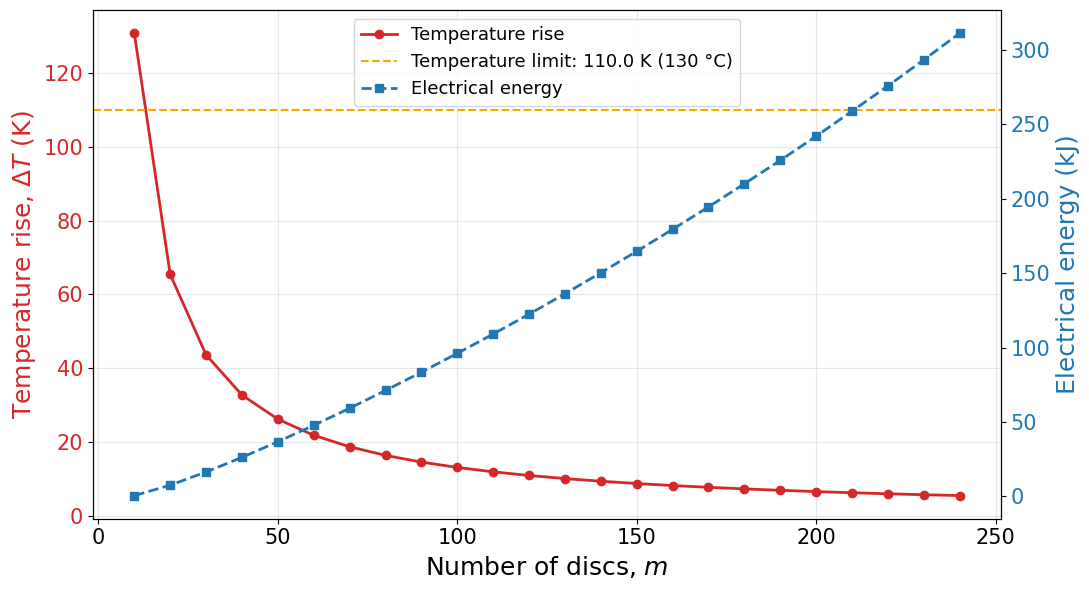

✓ Saved: OUTPUT/phase4_sweep_current.png


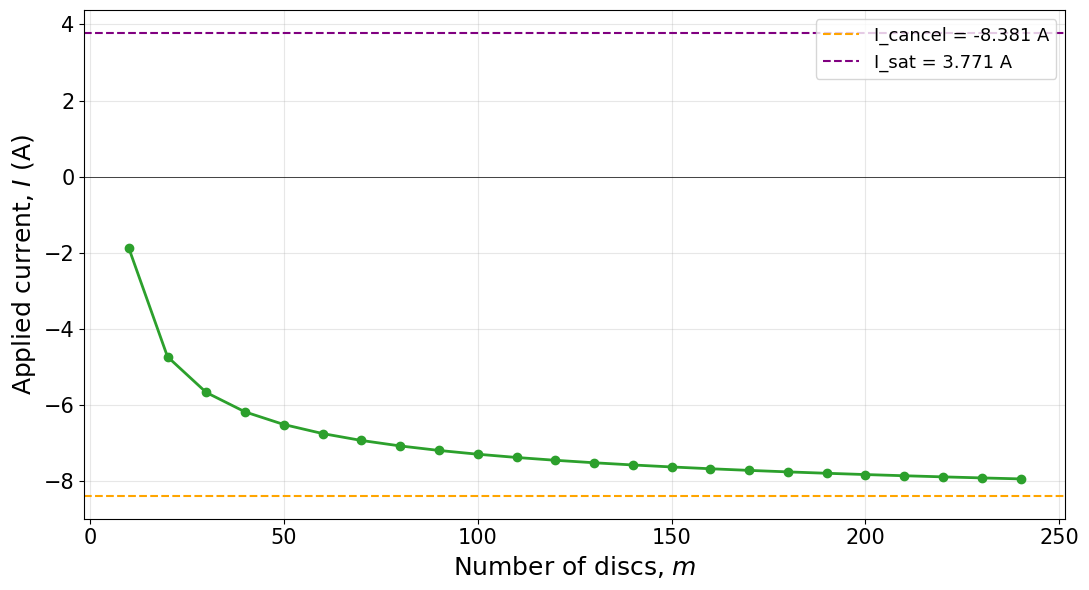


SWEEP COMPLETE


In [ ]:
"""
PHASE 4: System Dynamics & Thermal Model (HYBRID PM + EM)
MR Fluid Brake Feasibility Study - Hyperspace Mountain
TARGET DECELERATION: 0.5g
Starting from I_cancel (zero braking), search positive direction.

Torque convention (n = number of fluid gaps = 2 * m_discs):
  T_on  = (2 pi n / 3) tau_y (r_o^3 - r_i^3)
  T_off = (pi n mu omega / (2 d)) (r_o^4 - r_i^4)
Both expressions use n = number of gaps, consistently.

This version sweeps the number of discs m_discs over a range of values,
runs the full braking simulation for each, and plots the resulting
temperature rise and total electrical energy against m_discs.

THERMAL MODEL (THREE-NODE, PER UNIT):
  Coil:     heats from Joule heating (I^2 R), cools by conduction to housing.
  Fluid:    heats from mechanical work on the fluid, cools by conduction
            across the MR gap into the housing/stator.
  Housing:  receives heat from coil and fluid, loses heat to air by convection.

  All thermal ODEs are PER UNIT (one disc, two coils, two MR gaps).
  P_fluid_unit = (T_on_total + T_off_total) * omega / m_discs
  m_fluid_unit = 2 * pi * (r_o^2 - r_i^2) * d * rho   (per unit)

FEASIBILITY: For small m_discs the brake cannot produce enough torque to
reach the target deceleration even at saturation. Those cases are flagged
as infeasible and marked with NaN.

Relative permeability of MRF-132DG: 3.798 (MDPI Designs 2024,
DOI 10.3390/designs8020025).

Saturation field: B is capped at 1.16 T. Gives I_sat = 3.771 A.

Wire gauge: AWG 20 (0.812 mm diameter).
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =============================================================================
# STEP 1: Fixed Parameters
# =============================================================================

# Train parameters
m_train = 10000      # kg
v = 20               # m/s
R_wheel = 0.10       # m
s = 30               # Stopping distance (m)

# Brake geometry (fixed)
r_i = 0.05           # m
r_o = 0.15           # m
d = 0.005            # m [5 mm]
t_disc = 0.005       # m [5 mm]

# MR fluid properties
mu = 0.112           # Pa·s
rho = 3000           # kg/m³
Cp = 800             # J/(kg·K)

# Magnetic circuit
N_turns = 100
mu_0 = 4 * np.pi * 1e-7
mu_r_MR = 3.798
B_PM_per_side = 0.4
B_PM_total = 2 * B_PM_per_side
B_sat = 1.16

# Coil parameters
r_mean_coil = 0.10
wire_diameter = 0.812e-3
wire_area = np.pi * (wire_diameter / 2)**2
rho_copper_20C = 1.68e-8
alpha_copper = 0.00393
n_coils_per_unit = 2
l_wire_one_coil = 2 * np.pi * r_mean_coil * N_turns

# Thermal parameters
T_ambient = 20.0
T_limit_rise = 110.0   # 110 K rise -> 130 °C absolute

# Three-node thermal parameters
rho_steel = 7850.0
r_housing_out = 0.18
r_housing_in = 0.17
L_housing = 0.22
V_tube = np.pi * (r_housing_out**2 - r_housing_in**2) * L_housing
V_caps = 2 * np.pi * (r_housing_out**2 - r_i**2) * (r_housing_out - r_housing_in)
V_housing = V_tube + V_caps
m_housing = rho_steel * V_housing
Cp_steel = 500.0
A_housing = 0.452

# Coil thermal mass (PER UNIT)
rho_copper_density = 8960.0
V_wire_one_unit = n_coils_per_unit * l_wire_one_coil * wire_area
m_coil = rho_copper_density * V_wire_one_unit
Cp_copper = 385.0

# Fluid mass PER UNIT
m_fluid_unit = 2 * np.pi * (r_o**2 - r_i**2) * d * rho

# Thermal resistances (PER UNIT)
h_eff_coil_housing = 300.0
A_coil_surface = 0.102
R_CH = 1.0 / (h_eff_coil_housing * A_coil_surface)

k_F_eff = 0.319
h_gap = k_F_eff / d
A_fluid_surface = 0.126
R_FH = 1.0 / (h_gap * A_fluid_surface)

# Simulation parameters
dt = 0.005
max_time = 60.0
max_steps = 20000

# Target deceleration
target_decel_ms2 = 0.5 * 9.81
target_decel_rad = target_decel_ms2 / R_wheel
omega_start = v / R_wheel

# Cancellation and saturation currents
I_cancel = -B_PM_total * d / (mu_0 * mu_r_MR * N_turns)
I_sat = (B_sat - B_PM_total) * d / (mu_0 * mu_r_MR * N_turns)

# =============================================================================
# STEP 2: Physics Functions
# =============================================================================

def calculate_B(I):
    B_EM_total = (mu_0 * mu_r_MR * N_turns * I) / d
    B_total = B_PM_total + B_EM_total
    return max(min(B_total, B_sat), -B_sat)

def yield_stress_from_B(B):
    B_abs = abs(B)
    tau_y_kPa = 52.962 * B_abs**4 - 176.51 * B_abs**3 + 158.79 * B_abs**2 + 13.708 * B_abs + 0.1442
    return tau_y_kPa * 1000

def tau_y_from_I(I):
    return yield_stress_from_B(calculate_B(I))

def T_on(I, n):
    tau_y = tau_y_from_I(I)
    return (2 * np.pi * n * tau_y / 3) * (r_o**3 - r_i**3)

def T_off(omega, n):
    return (np.pi * n * mu * omega / (2 * d)) * (r_o**4 - r_i**4)

def T_total(I, omega, n):
    return T_on(I, n) + T_off(omega, n)

def R_unit(T_coil):
    rho_copper = rho_copper_20C * (1 + alpha_copper * (T_coil - 20.0))
    return n_coils_per_unit * rho_copper * l_wire_one_coil / wire_area

def P_elec_total(I, T_coil, m_discs):
    return m_discs * I**2 * R_unit(T_coil)

def h_convection(v):
    v_abs = max(abs(v), 0.0)
    return 8.0 * (v_abs ** 0.75)

# =============================================================================
# STEP 3: Single-Case Simulation Function (THREE-NODE THERMAL, PER UNIT)
# =============================================================================

def run_case(m_discs):
    n = 2 * m_discs

    def deceleration_error(I):
        T_now = T_total(I, omega_start, n)
        return T_now / (m_train * R_wheel**2) - target_decel_rad

    decel_max = (T_total(I_sat, omega_start, n) / (m_train * R_wheel**2)) * R_wheel
    if decel_max < target_decel_ms2:
        return None, None, None

    I_low = I_cancel
    I_high = I_sat
    for _ in range(60):
        I_mid = 0.5 * (I_low + I_high)
        err = deceleration_error(I_mid)
        if abs(err) < 1e-10:
            break
        if err > 0:
            I_high = I_mid
        else:
            I_low = I_mid
    I_applied = 0.5 * (I_low + I_high)

    T_coil = T_ambient
    T_fluid = T_ambient
    T_housing = T_ambient

    omega = v / R_wheel
    time = 0.0

    time_array = []
    T_coil_array = []
    T_fluid_array = []
    T_housing_array = []
    P_elec_array = []

    step = 0
    while omega > 0.001 and time < max_time and step < max_steps:
        step += 1

        T_on_now = T_on(I_applied, n)
        T_off_now = T_off(omega, n)
        T_total_now = T_on_now + T_off_now

        P_elec_now = P_elec_total(I_applied, T_coil, m_discs)

        P_fluid_unit = (T_on_now + T_off_now) * omega / m_discs
        P_elec_unit = P_elec_now / m_discs

        v_now = omega * R_wheel
        h_now = h_convection(v_now)
        P_cond_CH_unit = (T_coil - T_housing) / R_CH
        P_cond_FH_unit = (T_fluid - T_housing) / R_FH
        P_conv_H_unit = h_now * A_housing * (T_housing - T_ambient)

        dT_coil = (P_elec_unit - P_cond_CH_unit) * dt / (m_coil * Cp_copper)
        dT_fluid = (P_fluid_unit - P_cond_FH_unit) * dt / (m_fluid_unit * Cp)
        dT_housing = (P_cond_CH_unit + P_cond_FH_unit - P_conv_H_unit) * dt \
                     / (m_housing * Cp_steel)

        T_coil += dT_coil
        T_fluid += dT_fluid
        T_housing += dT_housing

        alpha = T_total_now / (m_train * R_wheel**2)
        omega -= alpha * dt
        if omega < 0:
            omega = 0

        time_array.append(time)
        T_coil_array.append(T_coil)
        T_fluid_array.append(T_fluid)
        T_housing_array.append(T_housing)
        P_elec_array.append(P_elec_now)
        time += dt

    if len(time_array) > 1:
        E_elec = np.trapz(P_elec_array, time_array)
        max_T_fluid = max(T_fluid_array)
    else:
        E_elec = 0.0
        max_T_fluid = T_ambient

    max_temp_rise = max_T_fluid - T_ambient
    return max_temp_rise, E_elec, I_applied

# =============================================================================
# STEP 4: Sweep Over m_discs
# =============================================================================

m_discs_list = list(range(10, 250, 10))
temp_rise_list = []
energy_list = []
current_list = []

print("=" * 70)
print("SWEEP OVER NUMBER OF DISCS (THREE-NODE THERMAL MODEL, PER UNIT)")
print("=" * 70)
print(f"mu_r_MR = {mu_r_MR:.3f}")
print(f"B_sat   = {B_sat:.2f} T")
print(f"I_cancel = {I_cancel:.4f} A")
print(f"I_sat    = {I_sat:.4f} A")
print(f"Wire gauge: AWG 20 (d = {wire_diameter*1000:.3f} mm)")
print(f"m_coil (per unit):    {m_coil:.4f} kg")
print(f"m_fluid (per unit):   {m_fluid_unit:.4f} kg")
print(f"m_housing (per unit): {m_housing:.2f} kg")
print(f"R_CH = {R_CH:.4f} K/W")
print(f"R_FH = {R_FH:.6f} K/W")
print("-" * 70)
print(f"{'m_discs':>8} | {'I_applied (A)':>14} | {'dT (K)':>10} | {'E_elec (kJ)':>12}")
print("-" * 70)

for m_discs in m_discs_list:
    dT, E_elec, I_app = run_case(m_discs)
    if dT is None:
        temp_rise_list.append(np.nan)
        energy_list.append(np.nan)
        current_list.append(np.nan)
        print(f"{m_discs:>8} | {'INFEASIBLE':>14} | {'---':>10} | {'---':>12}")
    else:
        temp_rise_list.append(dT)
        energy_list.append(E_elec / 1000.0)
        current_list.append(I_app)
        print(f"{m_discs:>8} | {I_app:>14.4f} | {dT:>10.2f} | {E_elec/1000:>12.2f}")

# =============================================================================
# STEP 5: Marginal Analysis Table
# =============================================================================

print("\n" + "=" * 78)
print("MARGINAL ANALYSIS: what each additional step in m_discs buys and costs")
print("=" * 78)
print(f"{'Step':>18} | {'dT reduction (K)':>17} | {'dE increase (kJ)':>17} | {'dT/dE (K/kJ)':>13}")
print("-" * 78)

for i in range(1, len(m_discs_list)):
    m_prev = m_discs_list[i-1]
    m_curr = m_discs_list[i]

    dT_prev = temp_rise_list[i-1]
    dT_curr = temp_rise_list[i]
    E_prev = energy_list[i-1]
    E_curr = energy_list[i]

    if np.isnan(dT_prev) or np.isnan(dT_curr) or np.isnan(E_prev) or np.isnan(E_curr):
        continue

    dT_reduction = dT_prev - dT_curr
    dE_increase = E_curr - E_prev

    if dE_increase > 0:
        ratio = dT_reduction / dE_increase
    else:
        ratio = float('inf')

    print(f"{m_prev:>7} -> {m_curr:<7} | {dT_reduction:>17.2f} | {dE_increase:>17.2f} | {ratio:>13.4f}")

print("-" * 78)
print("Interpretation:")
print("  dT reduction    : how many K of cooling you gain by adding discs")
print("  dE increase     : how many kJ of extra energy you pay for it")
print("  dT/dE           : K of cooling per kJ of extra energy (higher is better)")
print("  A falling dT/dE signals diminishing returns on additional discs.")
print("=" * 78)

# =============================================================================
# STEP 6: Plot Temperature Rise and Electrical Energy vs m_discs
# (rectangular, 800 dpi, no title, output to OUTPUT/ folder)
# =============================================================================

OUTPUT_DIR = Path("OUTPUT")
OUTPUT_DIR.mkdir(exist_ok=True)

FIG_SIZE = (11, 6)   # rectangular

fig, ax1 = plt.subplots(figsize=FIG_SIZE)

color1 = 'tab:red'
ax1.set_xlabel('Number of discs, $m$', fontsize=18)
ax1.set_ylabel(r'Temperature rise, $\Delta T$ (K)', color=color1, fontsize=18)
ax1.plot(m_discs_list, temp_rise_list, 'o-', color=color1,
         linewidth=2, markersize=6, label='Temperature rise')
ax1.tick_params(axis='y', labelcolor=color1, labelsize=15)
ax1.tick_params(axis='x', labelsize=15)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=T_limit_rise, color='orange', linestyle='--',
            label=f'Temperature limit: {T_limit_rise} K (130 °C)')

ax2 = ax1.twinx()
color2 = 'tab:blue'
ax2.set_ylabel('Electrical energy (kJ)', color=color2, fontsize=18)
ax2.plot(m_discs_list, energy_list, 's--', color=color2,
         linewidth=2, markersize=6, label='Electrical energy')
ax2.tick_params(axis='y', labelcolor=color2, labelsize=15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', fontsize=13)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase4_sweep_m_discs.png", dpi=800, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_DIR / 'phase4_sweep_m_discs.png'}")
plt.show()

# =============================================================================
# STEP 7: Secondary Plot - Current vs m_discs
# (rectangular, 800 dpi, no title, OUTPUT/)
# =============================================================================

fig2, ax3 = plt.subplots(figsize=FIG_SIZE)

ax3.plot(m_discs_list, current_list, 'o-', color='tab:green',
         linewidth=2, markersize=6)
ax3.axhline(y=I_cancel, color='orange', linestyle='--',
            label=f'I_cancel = {I_cancel:.3f} A')
ax3.axhline(y=I_sat, color='purple', linestyle='--',
            label=f'I_sat = {I_sat:.3f} A')
ax3.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax3.set_xlabel('Number of discs, $m$', fontsize=18)
ax3.set_ylabel('Applied current, $I$ (A)', fontsize=18)
ax3.tick_params(axis='both', labelsize=15)
ax3.grid(True, alpha=0.3)
ax3.legend(loc='upper right', fontsize=13)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase4_sweep_current.png", dpi=800, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_DIR / 'phase4_sweep_current.png'}")
plt.show()

print("\n" + "=" * 70)
print("SWEEP COMPLETE")
print("=" * 70)

Searching for t_end such that the total peak deceleration fits under the cap...
mu_r_MR = 3.798
I_cancel = -8.3810 A
I_sat    = 2.0952 A

t_end = 1.00 s, A_bell = 46.137 m/s², peak = 46.555 m/s² (4.746 g)
t_end = 1.05 s, A_bell = 43.894 m/s², peak = 44.312 m/s² (4.517 g)
t_end = 1.10 s, A_bell = 41.855 m/s², peak = 42.272 m/s² (4.309 g)
t_end = 1.15 s, A_bell = 39.992 m/s², peak = 40.410 m/s² (4.119 g)
t_end = 1.20 s, A_bell = 38.286 m/s², peak = 38.702 m/s² (3.945 g)
t_end = 1.25 s, A_bell = 36.715 m/s², peak = 37.132 m/s² (3.785 g)
t_end = 1.30 s, A_bell = 35.266 m/s², peak = 35.682 m/s² (3.637 g)
t_end = 1.35 s, A_bell = 33.924 m/s², peak = 34.340 m/s² (3.500 g)
t_end = 1.40 s, A_bell = 32.678 m/s², peak = 33.093 m/s² (3.373 g)
t_end = 1.45 s, A_bell = 31.517 m/s², peak = 31.933 m/s² (3.255 g)
t_end = 1.50 s, A_bell = 30.435 m/s², peak = 30.850 m/s² (3.145 g)
t_end = 1.55 s, A_bell = 29.422 m/s², peak = 29.836 m/s² (3.041 g)
t_end = 1.60 s, A_bell = 28.472 m/s², peak = 28.887 m/s² (

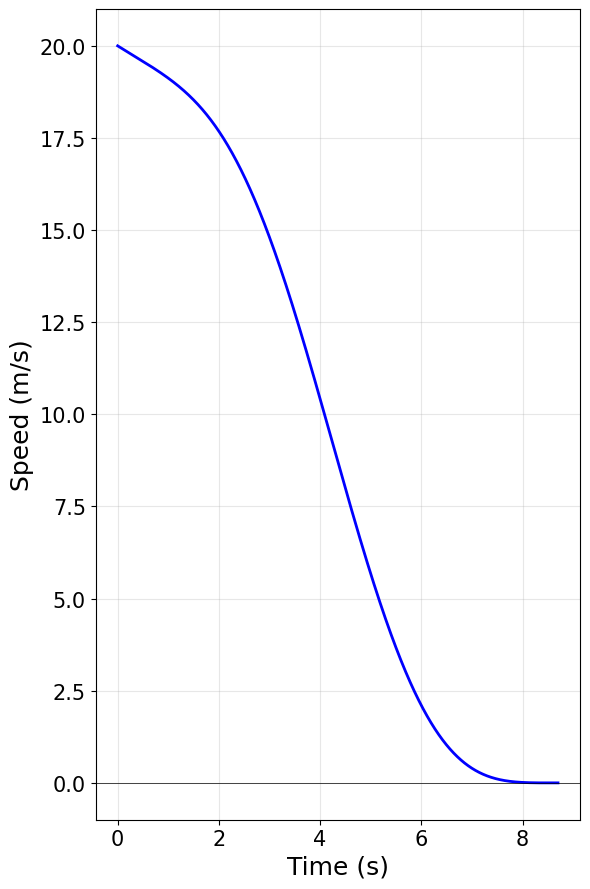

✓ Saved: OUTPUT/bell_decel_vs_time.png


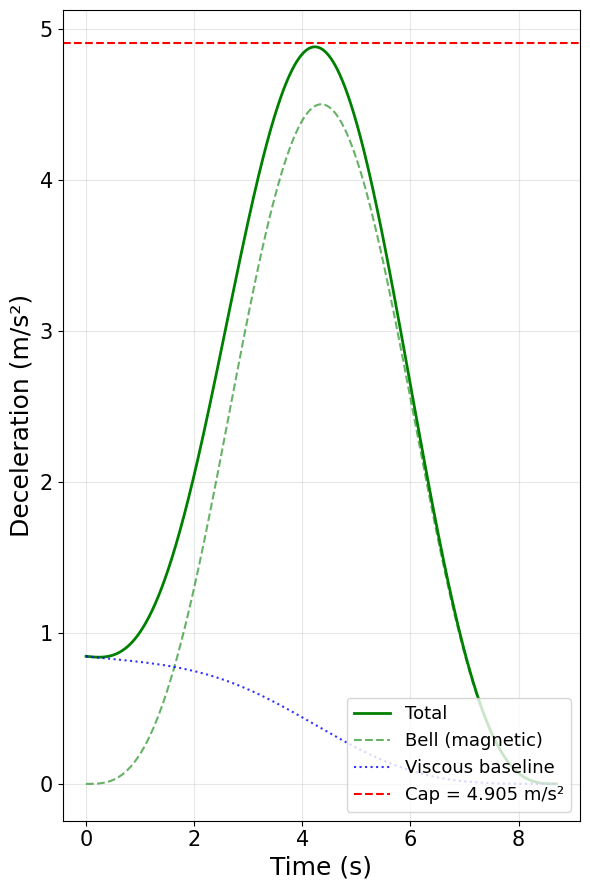

✓ Saved: OUTPUT/bell_jerk_vs_time.png


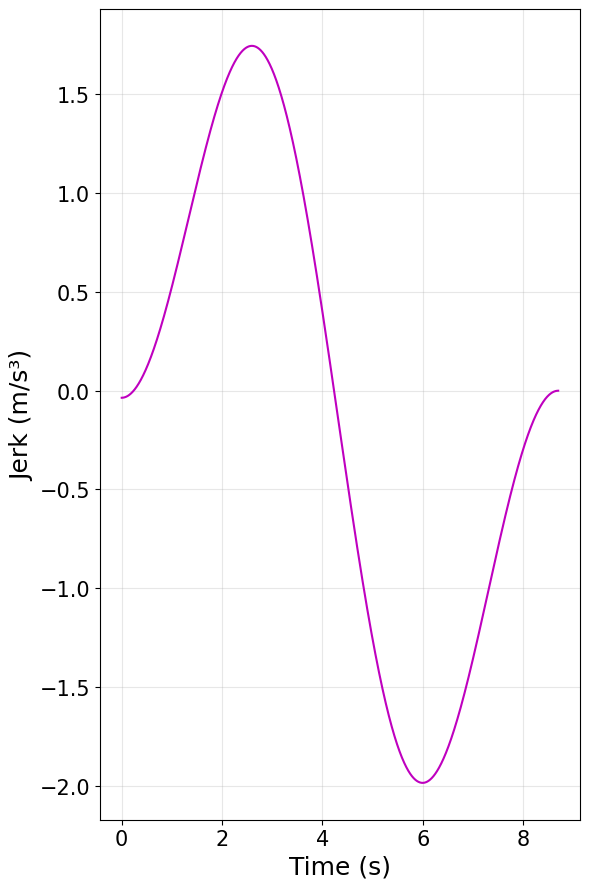

✓ Saved: OUTPUT/bell_distance_vs_time.png


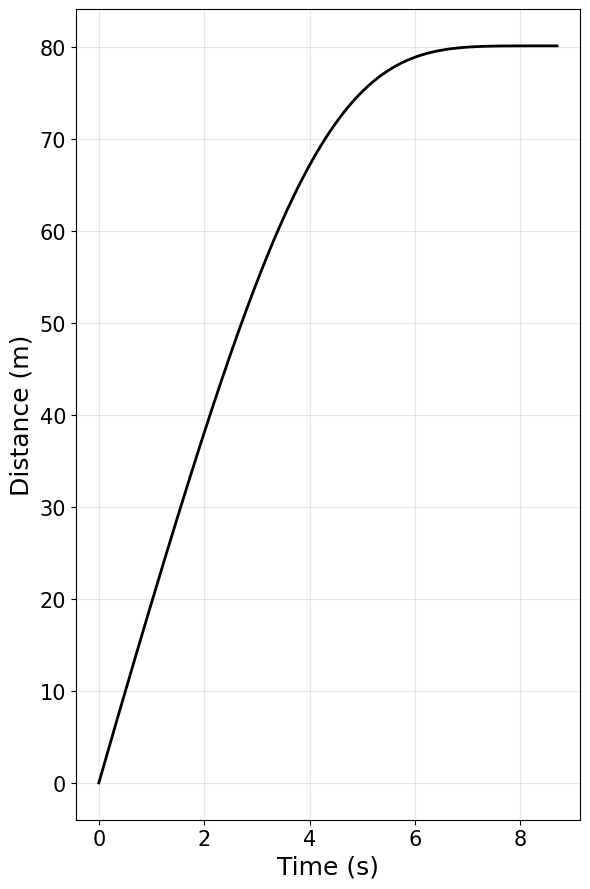

✓ Saved: OUTPUT/bell_current_vs_time.png


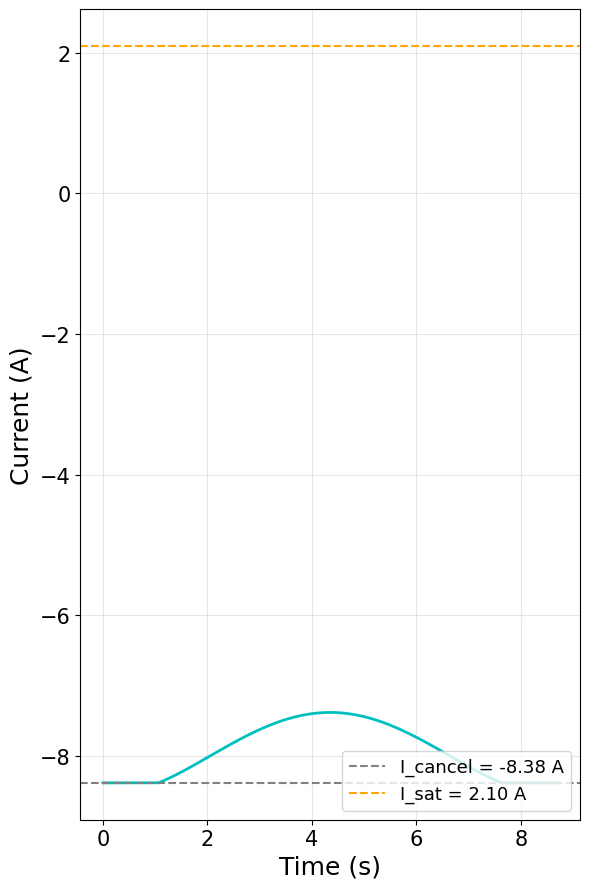

✓ Saved: OUTPUT/bell_torque_vs_time.png


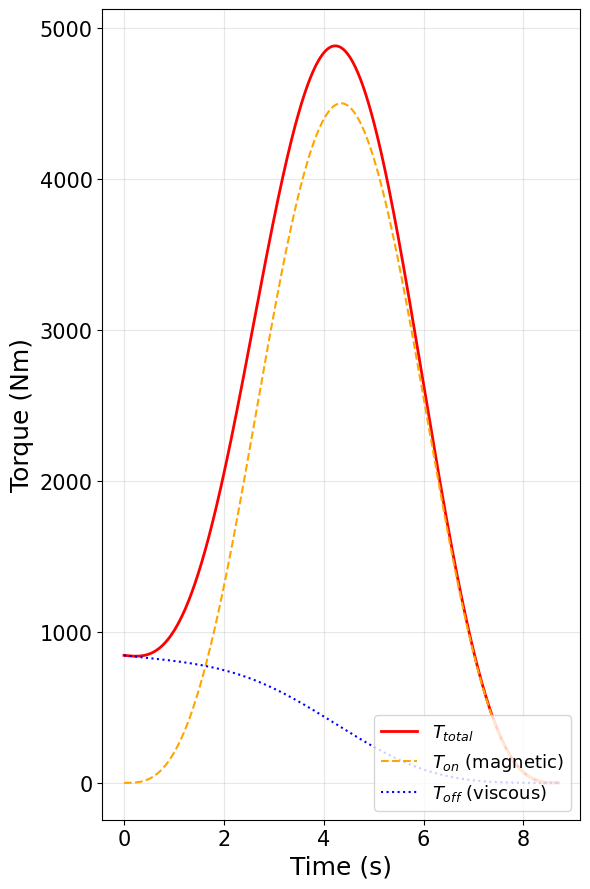

In [ ]:
"""
BELL-SHAPED DECELERATION PROFILE (raised-sine bell) WITH VISCOUS BASELINE

- Peak TOTAL deceleration = 0.5g (hard constraint)
- Train stops exactly at t_end (impulse condition enforced)
- Self-consistent: speed, deceleration, jerk, distance all integrate correctly

Torque convention (n = number of fluid gaps = 2 * m_discs):
  T_on  = (2 pi n / 3) tau_y (r_o^3 - r_i^3)
  T_off = (pi n mu omega / (2 d)) (r_o^4 - r_i^4)

Relative permeability of MRF-132DG: 3.798 (MDPI Designs 2024,
DOI 10.3390/designs8020025). Published values range from ~2.78 to 5.0
depending on field strength and measurement method.
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUT_DIR = Path("OUTPUT")
OUTPUT_DIR.mkdir(exist_ok=True)

# =============================================================================
# PARAMETERS
# =============================================================================

v0 = 20.0                # Initial speed (m/s)
a_cap = 0.5 * 9.81       # Peak deceleration cap (m/s²)
dt = 0.001               # Time step (s)
shape_exp = 3.0          # Bell sharpness

# =============================================================================
# BRAKE MODEL PARAMETERS
# =============================================================================

m_train = 10000.0
R_wheel = 0.10
r_i = 0.05
r_o = 0.15
d = 0.005
m_discs = 120
n_gaps = 2 * m_discs
mu_full = 0.112

N_turns = 100
mu_0 = 4 * np.pi * 1e-7
mu_r_MR = 3.798
B_PM_per_side = 0.4
B_PM_total = 2 * B_PM_per_side
B_sat = 1.0

dB_dI = mu_0 * mu_r_MR * N_turns / d
I_cancel = -B_PM_total * d / (mu_0 * mu_r_MR * N_turns)
I_sat = (B_sat - B_PM_total) * d / (mu_0 * mu_r_MR * N_turns)

_trapz = getattr(np, 'trapezoid', None)
if _trapz is None:
    _trapz = np.trapz

# =============================================================================
# PHYSICS FUNCTIONS
# =============================================================================

def calculate_B(I):
    B_EM = (mu_0 * mu_r_MR * N_turns * I) / d
    return max(min(B_PM_total + B_EM, B_sat), -B_sat)

def yield_stress_from_B(B):
    B_abs = abs(B)
    tau_y_kPa = (52.962*B_abs**4 - 176.51*B_abs**3
                 + 158.79*B_abs**2 + 13.708*B_abs + 0.1442)
    return tau_y_kPa * 1000

def T_on(I):
    tau_y = yield_stress_from_B(calculate_B(I))
    return (2*np.pi*n_gaps*tau_y/3)*(r_o**3 - r_i**3)

def T_off(omega):
    return (np.pi*n_gaps*mu_full*omega/(2*d))*(r_o**4 - r_i**4)

def a_viscous(v):
    omega = v / R_wheel
    return T_off(omega) / (m_train * R_wheel)

def bell(t, t_end, exponent):
    s = np.sin(np.pi * t / t_end)
    s = np.clip(s, 0.0, 1.0)
    return s**exponent

# =============================================================================
# SIMULATE THE KINEMATICS
# =============================================================================

def simulate(t_end, A_bell, exponent):
    t = np.arange(0, t_end + dt, dt)
    v = np.zeros_like(t)
    a_bell_arr = np.zeros_like(t)
    a_visc_arr = np.zeros_like(t)
    a_total_arr = np.zeros_like(t)
    x = np.zeros_like(t)
    v[0] = v0

    for i in range(len(t)):
        a_bell_arr[i] = A_bell * bell(t[i], t_end, exponent)
        a_visc_arr[i] = a_viscous(v[i])
        a_total_arr[i] = a_bell_arr[i] + a_visc_arr[i]
        if i < len(t) - 1:
            v[i+1] = max(0.0, v[i] - a_total_arr[i] * dt)
            x[i+1] = x[i] + v[i+1] * dt

    j = np.gradient(a_total_arr, t)
    return t, v, a_bell_arr, a_visc_arr, a_total_arr, x, j

def solve_A_bell(t_end, exponent, n_iter=8):
    t_arr = np.arange(0, t_end + dt, dt)
    unit_bell_impulse = _trapz(bell(t_arr, t_end, exponent), t_arr)
    if unit_bell_impulse <= 0:
        return None
    A = 0.0
    for _ in range(n_iter):
        _, v, _, a_visc_arr, _, _, _ = simulate(t_end, A, exponent)
        viscous_impulse = _trapz(a_visc_arr, t_arr)
        bell_impulse_needed = v0 - viscous_impulse
        A_new = bell_impulse_needed / unit_bell_impulse
        if abs(A_new - A) < 1e-8:
            A = A_new
            break
        A = A_new
    return A

# =============================================================================
# FIND THE SMALLEST t_end FOR WHICH THE PEAK FITS UNDER a_cap
# =============================================================================

print("Searching for t_end such that the total peak deceleration fits under the cap...")
print(f"mu_r_MR = {mu_r_MR:.3f}")
print(f"I_cancel = {I_cancel:.4f} A")
print(f"I_sat    = {I_sat:.4f} A")
print()

t_end = 1.0
A_final = None
t_final = None

while t_end < 30.0:
    A_candidate = solve_A_bell(t_end, shape_exp)
    if A_candidate is None:
        t_end += 0.05
        continue
    _, _, _, _, a_total_arr, _, _ = simulate(t_end, A_candidate, shape_exp)
    peak = np.max(a_total_arr)
    print(f"t_end = {t_end:.2f} s, A_bell = {A_candidate:.3f} m/s², "
          f"peak = {peak:.3f} m/s² ({peak/9.81:.3f} g)")
    if peak <= a_cap:
        A_final = A_candidate
        t_final = t_end
        break
    t_end += 0.05

if A_final is None:
    raise SystemExit("Could not satisfy the 0.5g cap with the impulse condition.")

t, v, a_bell_arr, a_visc_arr, a_total_arr, x, j = simulate(t_final, A_final, shape_exp)

# =============================================================================
# SELF-CONSISTENCY CHECKS
# =============================================================================

print("\n" + "=" * 60)
print("SELF-CONSISTENCY CHECKS")
print("=" * 60)
print(f"t_end:             {t_final:.4f} s")
print(f"Bell amplitude:    {A_final:.4f} m/s² ({A_final/9.81:.3f} g)")

impulse = _trapz(a_total_arr, t)
print(f"\nIntegral of a_total dt = {impulse:.4f} m/s")
print(f"Initial speed          = {v0:.4f} m/s")
print(f"Residual (should be 0) = {impulse - v0:.6e} m/s")
print(f"Final speed            = {v[-1]:.6f} m/s")

print(f"\na_total(0):        {a_total_arr[0]:.6f} m/s²")
print(f"a_total peak:      {np.max(a_total_arr):.4f} m/s² ({np.max(a_total_arr)/9.81:.3f} g)")
print(f"Stopping distance: {x[-1]:.4f} m")
print(f"Peak |jerk|:       {np.max(np.abs(j)):.4f} m/s³")

# =============================================================================
# BRAKE MODEL VERIFICATION
# =============================================================================

print("\n" + "=" * 60)
print("BRAKE MODEL VERIFICATION")
print("=" * 60)
print(f"dB/dI             = {dB_dI:.4f} T/A")
print(f"I_cancel          = {I_cancel:.4f} A")
print(f"I_sat             = {I_sat:.4f} A")

omega_arr = v / R_wheel
I_required = []
T_on_required = []
T_total_required = []
T_off_required = []

for i in range(len(t)):
    if omega_arr[i] <= 1e-6:
        I_required.append(I_cancel)
        T_on_required.append(0.0)
        T_total_required.append(0.0)
        T_off_required.append(0.0)
        continue
    T_total_req = m_train * R_wheel * a_total_arr[i]
    T_off_now = T_off(omega_arr[i])
    T_on_req = max(T_total_req - T_off_now, 0.0)
    T_total_required.append(T_total_req)
    T_off_required.append(T_off_now)
    T_on_required.append(T_on_req)
    if T_on_req < 1e-6:
        I_required.append(I_cancel)
    else:
        I_lo, I_hi = I_cancel, I_sat
        for _ in range(40):
            I_mid = 0.5*(I_lo + I_hi)
            if T_on(I_mid) > T_on_req:
                I_hi = I_mid
            else:
                I_lo = I_mid
        I_required.append(0.5*(I_lo + I_hi))

I_required = np.array(I_required)
T_on_required = np.array(T_on_required)
T_total_required = np.array(T_total_required)
T_off_required = np.array(T_off_required)

print(f"\nRequired current during braking:")
print(f"  min  = {I_required.min():.4f} A")
print(f"  max  = {I_required.max():.4f} A")
print(f"  at peak total decel = {I_required[np.argmax(a_total_arr)]:.4f} A")

# =============================================================================
# FIGURES: ALL SEPARATED, 800 DPI, NO TITLES, TALLER THAN WIDE
# =============================================================================

FIG_SIZE = (6, 9)   # taller than wide (portrait)

# -------------------------------------------------------------------------
# Figure A: Speed vs Time
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.plot(t, v, 'b-', linewidth=2)
ax.set_xlabel('Time (s)', fontsize=18)
ax.set_ylabel('Speed (m/s)', fontsize=18)
ax.tick_params(axis='both', labelsize=15)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bell_speed_vs_time.png", dpi=800, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_DIR / 'bell_speed_vs_time.png'}")
plt.show()

# -------------------------------------------------------------------------
# Figure B: Deceleration vs Time
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.plot(t, a_total_arr, 'g-', linewidth=2, label='Total')
ax.plot(t, a_bell_arr, 'g--', linewidth=1.5, alpha=0.6, label='Bell (magnetic)')
ax.plot(t, a_visc_arr, 'b:', linewidth=1.5, alpha=0.8, label='Viscous baseline')
ax.axhline(y=a_cap, color='r', linestyle='--',
           label=f'Cap = {a_cap:.3f} m/s²')
ax.set_xlabel('Time (s)', fontsize=18)
ax.set_ylabel('Deceleration (m/s²)', fontsize=18)
ax.tick_params(axis='both', labelsize=15)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bell_decel_vs_time.png", dpi=800, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_DIR / 'bell_decel_vs_time.png'}")
plt.show()

# -------------------------------------------------------------------------
# Figure C: Jerk vs Time
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.plot(t, j, 'm-', linewidth=1.5)
ax.set_xlabel('Time (s)', fontsize=18)
ax.set_ylabel('Jerk (m/s³)', fontsize=18)
ax.tick_params(axis='both', labelsize=15)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bell_jerk_vs_time.png", dpi=800, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_DIR / 'bell_jerk_vs_time.png'}")
plt.show()

# -------------------------------------------------------------------------
# Figure D: Distance vs Time
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.plot(t, x, 'k-', linewidth=2)
ax.set_xlabel('Time (s)', fontsize=18)
ax.set_ylabel('Distance (m)', fontsize=18)
ax.tick_params(axis='both', labelsize=15)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bell_distance_vs_time.png", dpi=800, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_DIR / 'bell_distance_vs_time.png'}")
plt.show()

# -------------------------------------------------------------------------
# Figure E: Required Current vs Time
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.plot(t, I_required, 'c-', linewidth=2)
ax.axhline(y=I_cancel, color='gray', linestyle='--',
           label=f'I_cancel = {I_cancel:.2f} A')
ax.axhline(y=I_sat, color='orange', linestyle='--',
           label=f'I_sat = {I_sat:.2f} A')
ax.set_xlabel('Time (s)', fontsize=18)
ax.set_ylabel('Current (A)', fontsize=18)
ax.tick_params(axis='both', labelsize=15)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bell_current_vs_time.png", dpi=800, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_DIR / 'bell_current_vs_time.png'}")
plt.show()

# -------------------------------------------------------------------------
# Figure F: Torque Breakdown vs Time
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.plot(t, T_total_required, 'r-', linewidth=2, label=r'$T_{total}$')
ax.plot(t, T_on_required, 'orange', linestyle='--',
        linewidth=1.5, label=r'$T_{on}$ (magnetic)')
ax.plot(t, T_off_required, 'b:', linewidth=1.5, label=r'$T_{off}$ (viscous)')
ax.set_xlabel('Time (s)', fontsize=18)
ax.set_ylabel('Torque (Nm)', fontsize=18)
ax.tick_params(axis='both', labelsize=15)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bell_torque_vs_time.png", dpi=800, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_DIR / 'bell_torque_vs_time.png'}")
plt.show()

UNIT-COUNT MULTIPLIERS (equal-force at v = 20 m/s)
Target force (MR at v = 20.0 m/s):  810.5 kN
Eddy per-unit force at v = 20.0 m/s:  9.2 kN
Friction per-unit force:                    16.0 kN

N_eddy     = 89 units
N_friction = 51 units

BRAKING FORCE vs SPEED COMPARISON

--- REFERENCE PARAMETERS ---
Top speed:              69.44 m/s (250 km/h)
Equal-force speed:      20.0 m/s
Relative permeability:  3.798
Cancellation current:   -8.3810 A
Saturation current:     3.7710 A
Eddy nominal speed:     79.8 m/s
Eddy peak force:        38.9 kN per unit
Friction force:         16.0 kN per caliper (0.4 × 20,000 × 2)

--- TOTAL FORCES AT v = 20 m/s ---
MR:                     810.5 kN
Eddy (89 units):        816.4 kN
Friction (51 units):     816.0 kN

--- TOTAL FORCES AT TOP SPEED (69.4 m/s) ---
MR:                     831.3 kN
Eddy (89 units):        1714.5 kN
Friction (51 units):     816.0 kN
✓ Saved: OUTPUT/braking_force_vs_speed_per_unit.png


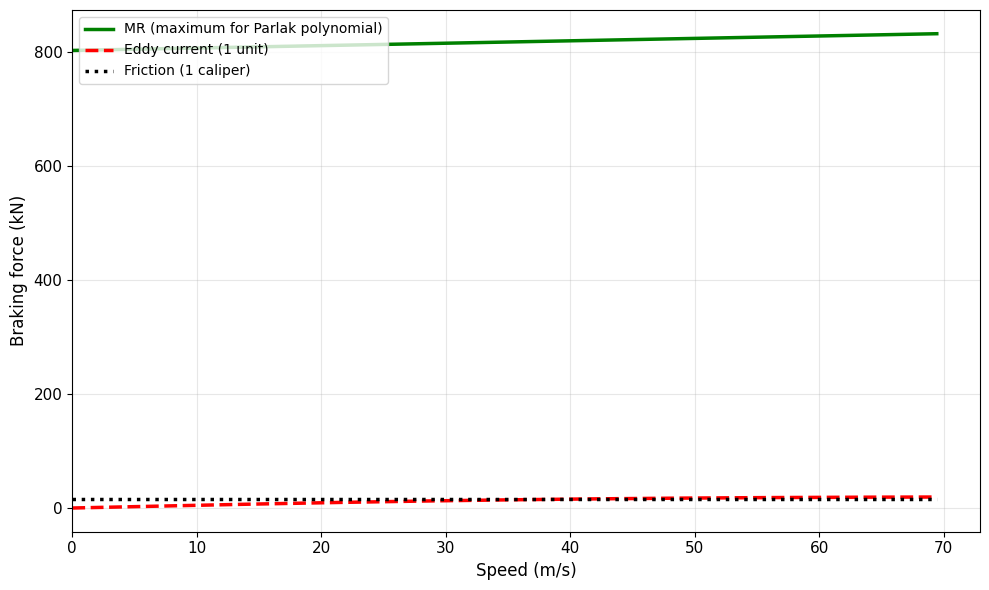

✓ Saved: OUTPUT/braking_force_vs_speed_total.png


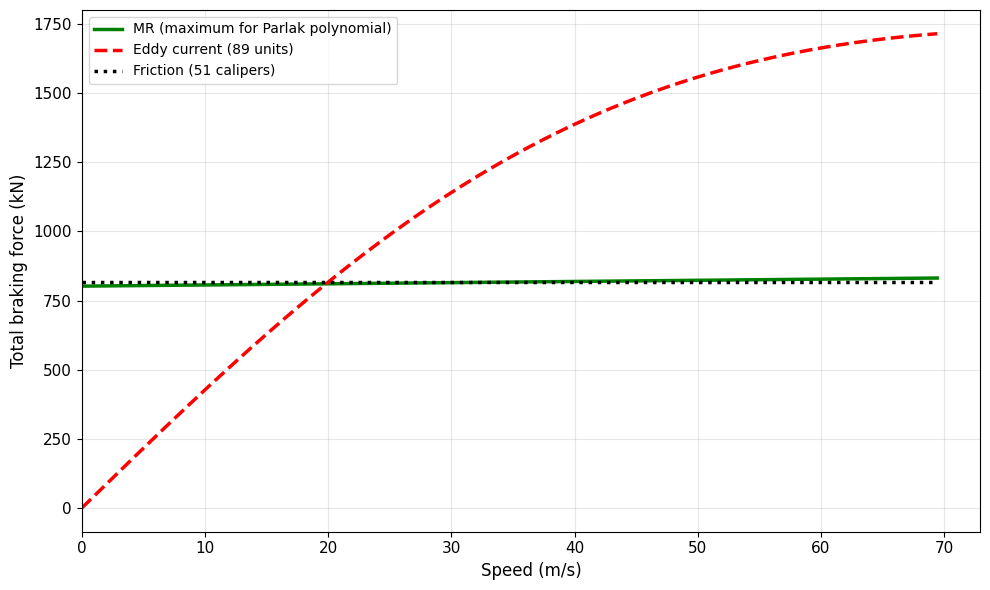


QUANTITATIVE SUMMARY

--- PER-UNIT FORCES (kN) ---

Speed (m/s)  | MR         | Eddy       | Friction  
------------------------------------------------
0.1          | 802.1      | 0.0        | 16.0      
5.0          | 804.1      | 2.4        | 16.0      
10.0         | 806.2      | 4.8        | 16.0      
15.0         | 808.4      | 7.1        | 16.0      
20.0         | 810.5      | 9.2        | 16.0      
30.0         | 814.7      | 12.8       | 16.0      
40.0         | 818.9      | 15.6       | 16.0      
50.0         | 823.1      | 17.5       | 16.0      
60.0         | 827.4      | 18.7       | 16.0      
69.4         | 831.3      | 19.3       | 16.0      

--- TOTAL FORCES (kN) ---

Speed (m/s)  | MR         | Eddy x N   | Fric. x N 
----------------------------------------------------
0.1          | 802.1      | 4.3        | 816.0     
5.0          | 804.1      | 216.1      | 816.0     
10.0         | 806.2      | 427.1      | 816.0     
15.0         | 808.4      | 628.6    

In [ ]:
"""
BRAKING FORCE vs SPEED COMPARISON
MR Brake vs Eddy Current Brake vs Friction Brake
Grounded in Falcon's Flight parameters (v0 = 69.44 m/s)

Corrected magnetic circuit: two coils and two gaps, so the 2s cancel and
B_EM = mu_0 * mu_r_MR * N * I / d (no extra factor of 2).

Torque convention (n = number of fluid gaps = 2 * m_discs):
  T_on  = (2 pi n / 3) tau_y (r_o^3 - r_i^3)
  T_off = (pi n mu omega / (2 d)) (r_o^4 - r_i^4)

Eddy current brake: Kloss's equation with
F_peak = 38.9 kN, v_nominal = 79.8 m/s.

Friction brake: mu_friction = 0.4, F_normal = 20,000 N,
                with a factor of 2 -> F_friction = 16,000 N per unit.

The equal-force point is v = 20 m/s. The number of eddy units and
friction calipers is chosen so that all three technologies produce the
same total braking force at v = 20 m/s.

Two figures are produced:

  Figure 1 (per-unit):  Each technology shown at its own per-unit scale.
                        One MR brake, one eddy unit, one friction caliper.

  Figure 2 (total):     The eddy and friction curves are multiplied by the
                        integer number of units required to match the MR
                        brake's force at v = 20 m/s.

The MR cancelled (carrier fluid) curve is omitted from both figures.

Relative permeability of MRF-132DG: 3.798 (MDPI Designs 2024,
DOI 10.3390/designs8020025). Published values range from ~2.78 to 5.0
depending on field strength and measurement method.
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUT_DIR = Path("OUTPUT")
OUTPUT_DIR.mkdir(exist_ok=True)

# =============================================================================
# FALCON'S FLIGHT PARAMETERS
# =============================================================================

v0 = 250 / 3.6          # 69.44 m/s, top speed
m_train = 10000.0       # kg
R_wheel = 0.10          # m

# =============================================================================
# MR BRAKE PARAMETERS (from Phase 2 and 4)
# =============================================================================

r_i = 0.05
r_o = 0.15
d = 0.005
m_discs = 120
n = 2 * m_discs

mu_full = 0.112         # Pa·s, full MR fluid
mu_carrier = 0.05       # Pa·s, carrier only (particles pulled aside)

N_turns = 100
mu_0 = 4 * np.pi * 1e-7
mu_r_MR = 3.798         # Relative permeability of MRF-132DG (MDPI Designs 2024)
B_PM_per_side = 0.4
B_PM_total = 2 * B_PM_per_side
B_sat = 1.0

# Cancellation current: zeroes the field in the gap
I_cancel = -B_PM_total * d / (mu_0 * mu_r_MR * N_turns)

# Saturation current: drives the field to B_sat (maximum useful braking)
I_sat = 3.771           # A

# =============================================================================
# EDDY CURRENT BRAKE PARAMETERS
# =============================================================================

v_nominal_eddy = 79.8      # m/s, speed at which force is maximum
F_peak_eddy = 38900.0      # N, peak braking force

def F_eddy(v):
    """Eddy current brake force vs speed (Kloss's equation)."""
    return F_peak_eddy * (v / v_nominal_eddy) / (1 + (v / v_nominal_eddy)**2)

# =============================================================================
# FRICTION BRAKE PARAMETERS
# =============================================================================

mu_friction = 0.4
F_normal = 20000.0      # N, clamp force
F_friction = mu_friction * F_normal * 2   # 0.4 × 20,000 × 2 = 16,000 N per unit

# =============================================================================
# MR BRAKE FORCE vs SPEED
# =============================================================================

def yield_stress_from_B(B):
    B_abs = abs(max(min(B, B_sat), -B_sat))
    tau_y_kPa = (52.962*B_abs**4 - 176.51*B_abs**3
                 + 158.79*B_abs**2 + 13.708*B_abs + 0.1442)
    return tau_y_kPa * 1000

def calculate_B(I):
    """Corrected: two coils, two gaps, the 2s cancel."""
    B_EM_total = (mu_0 * mu_r_MR * N_turns * I) / d
    return B_PM_total + B_EM_total

def T_on(I):
    tau_y = yield_stress_from_B(calculate_B(I))
    return (2*np.pi*n*tau_y/3)*(r_o**3 - r_i**3)

def T_off(omega, mu_fluid):
    return (np.pi*n*mu_fluid*omega/(2*d))*(r_o**4 - r_i**4)

def F_MR(v, I, mu_fluid):
    """MR brake force vs speed at a given current."""
    omega = v / R_wheel
    T_total = T_on(I) + T_off(omega, mu_fluid)
    return T_total / R_wheel

# =============================================================================
# COMPUTE THE UNIT-COUNT MULTIPLIERS AT v = 20 m/s
# =============================================================================

v_equal = 20.0          # m/s, the speed at which all three must be equal

F_target = F_MR(v_equal, I_sat, mu_full)
F_per_unit_eddy = F_eddy(v_equal)
F_per_unit_friction = F_friction

N_eddy = int(np.ceil(F_target / F_per_unit_eddy))
N_friction = int(np.ceil(F_target / F_per_unit_friction))

print("=" * 70)
print("UNIT-COUNT MULTIPLIERS (equal-force at v = 20 m/s)")
print("=" * 70)
print(f"Target force (MR at v = {v_equal:.1f} m/s):  {F_target/1000:.1f} kN")
print(f"Eddy per-unit force at v = {v_equal:.1f} m/s:  {F_per_unit_eddy/1000:.1f} kN")
print(f"Friction per-unit force:                    {F_per_unit_friction/1000:.1f} kN")
print()
print(f"N_eddy     = {N_eddy} units")
print(f"N_friction = {N_friction} units")

# =============================================================================
# SPEED RANGE
# =============================================================================

v_range = np.linspace(0, v0, 500)

# =============================================================================
# COMPUTE FORCES
# =============================================================================

F_MR_sat = np.array([F_MR(v, I_sat, mu_full) for v in v_range])

F_eddy_unit = np.array([F_eddy(v) for v in v_range])
F_friction_unit = np.full_like(v_range, F_friction)

F_eddy_total = F_eddy_unit * N_eddy
F_friction_total = F_friction_unit * N_friction

# =============================================================================
# REPORT
# =============================================================================

print("\n" + "=" * 70)
print("BRAKING FORCE vs SPEED COMPARISON")
print("=" * 70)

print(f"\n--- REFERENCE PARAMETERS ---")
print(f"Top speed:              {v0:.2f} m/s ({v0*3.6:.0f} km/h)")
print(f"Equal-force speed:      {v_equal:.1f} m/s")
print(f"Relative permeability:  {mu_r_MR:.3f}")
print(f"Cancellation current:   {I_cancel:.4f} A")
print(f"Saturation current:     {I_sat:.4f} A")
print(f"Eddy nominal speed:     {v_nominal_eddy:.1f} m/s")
print(f"Eddy peak force:        {F_peak_eddy/1000:.1f} kN per unit")
print(f"Friction force:         {F_friction/1000:.1f} kN per caliper (0.4 × 20,000 × 2)")

print(f"\n--- TOTAL FORCES AT v = 20 m/s ---")
print(f"MR:                     {F_MR(v_equal, I_sat, mu_full)/1000:.1f} kN")
print(f"Eddy ({N_eddy} units):        {N_eddy * F_eddy(v_equal)/1000:.1f} kN")
print(f"Friction ({N_friction} units):     {N_friction * F_friction/1000:.1f} kN")

print(f"\n--- TOTAL FORCES AT TOP SPEED ({v0:.1f} m/s) ---")
print(f"MR:                     {F_MR(v0, I_sat, mu_full)/1000:.1f} kN")
print(f"Eddy ({N_eddy} units):        {N_eddy * F_eddy(v0)/1000:.1f} kN")
print(f"Friction ({N_friction} units):     {N_friction * F_friction/1000:.1f} kN")

# =============================================================================
# FIGURE 1: PER-UNIT COMPARISON
# (800 dpi, no title, 10 x 6 dimensions)
# =============================================================================

FIG_SIZE = (10, 6)

fig1, ax1 = plt.subplots(figsize=FIG_SIZE)

ax1.plot(v_range, F_MR_sat / 1000, 'g-', linewidth=2.5,
         label='MR (maximum for Parlak polynomial)')
ax1.plot(v_range, F_eddy_unit / 1000, 'r--', linewidth=2.5,
         label='Eddy current (1 unit)')
ax1.plot(v_range, F_friction_unit / 1000, 'k:', linewidth=2.5,
         label='Friction (1 caliper)')

ax1.set_xlabel('Speed (m/s)', fontsize=12)
ax1.set_ylabel('Braking force (kN)', fontsize=12)
ax1.tick_params(axis='both', labelsize=11)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10, loc='upper left')
ax1.set_xlim(0, v0 * 1.05)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'braking_force_vs_speed_per_unit.png', dpi=800, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_DIR / 'braking_force_vs_speed_per_unit.png'}")
plt.show()

# =============================================================================
# FIGURE 2: TOTAL FORCE COMPARISON (equal-force at 20 m/s)
# (800 dpi, no title, 10 x 6 dimensions)
# =============================================================================

fig2, ax2 = plt.subplots(figsize=FIG_SIZE)

ax2.plot(v_range, F_MR_sat / 1000, 'g-', linewidth=2.5,
         label='MR (maximum for Parlak polynomial)')
ax2.plot(v_range, F_eddy_total / 1000, 'r--', linewidth=2.5,
         label=f'Eddy current ({N_eddy} units)')
ax2.plot(v_range, F_friction_total / 1000, 'k:', linewidth=2.5,
         label=f'Friction ({N_friction} calipers)')

ax2.set_xlabel('Speed (m/s)', fontsize=12)
ax2.set_ylabel('Total braking force (kN)', fontsize=12)
ax2.tick_params(axis='both', labelsize=11)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10, loc='upper left')
ax2.set_xlim(0, v0 * 1.05)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'braking_force_vs_speed_total.png', dpi=800, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_DIR / 'braking_force_vs_speed_total.png'}")
plt.show()

# =============================================================================
# QUANTITATIVE SUMMARY TABLE
# =============================================================================

print("\n" + "=" * 70)
print("QUANTITATIVE SUMMARY")
print("=" * 70)

speeds_to_check = [0.1, 5, 10, 15, 20, 30, 40, 50, 60, 69.4]

print("\n--- PER-UNIT FORCES (kN) ---")
print(f"\n{'Speed (m/s)':<12} | {'MR':<10} | {'Eddy':<10} | {'Friction':<10}")
print("-" * 48)
for v in speeds_to_check:
    mr_st = F_MR(v, I_sat, mu_full) / 1000
    ed = F_eddy(v) / 1000
    fr = F_friction / 1000
    print(f"{v:<12.1f} | {mr_st:<10.1f} | {ed:<10.1f} | {fr:<10.1f}")

print("\n--- TOTAL FORCES (kN) ---")
print(f"\n{'Speed (m/s)':<12} | {'MR':<10} | {'Eddy x N':<10} | {'Fric. x N':<10}")
print("-" * 52)
for v in speeds_to_check:
    mr_st = F_MR(v, I_sat, mu_full) / 1000
    ed = F_eddy(v) * N_eddy / 1000
    fr = F_friction * N_friction / 1000
    print(f"{v:<12.1f} | {mr_st:<10.1f} | {ed:<10.1f} | {fr:<10.1f}")

# =============================================================================
# KEY COMPARISONS
# =============================================================================

print("\n" + "=" * 70)
print("KEY COMPARISONS")
print("=" * 70)

print(f"\n--- TOTAL FORCE AT v = 20 m/s ---")
print(f"MR (1 unit):                 {F_MR(v_equal, I_sat, mu_full)/1000:.1f} kN")
print(f"Eddy current ({N_eddy} units):       {N_eddy * F_eddy(v_equal)/1000:.1f} kN")
print(f"Friction ({N_friction} calipers):         {N_friction * F_friction/1000:.1f} kN")
print(f"All three match by construction at v = 20 m/s.")

print(f"\n--- TOTAL FORCE AT TOP SPEED ---")
print(f"MR (1 unit):                 {F_MR(v0, I_sat, mu_full)/1000:.1f} kN")
print(f"Eddy current ({N_eddy} units):       {N_eddy * F_eddy(v0)/1000:.1f} kN")
print(f"Friction ({N_friction} calipers):         {N_friction * F_friction/1000:.1f} kN")

print(f"\n--- HOLDING FORCE AT STANDSTILL ---")
print(f"MR:                          {F_MR(0.001, I_sat, mu_full)/1000:.1f} kN")
print(f"Eddy current ({N_eddy} units):       0.0 kN  (cannot hold)")
print(f"Friction ({N_friction} calipers):         {N_friction * F_friction/1000:.1f} kN")

print("\n" + "=" * 70)
print("DONE")
print("=" * 70)

MAGNETIC CIRCUIT
B_PM (total)              = 0.8000 T
I_cancel                  = -8.3810 A
I_sat                     = 3.7714 A



/tmp/ipykernel_2227/1197146642.py:182: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  bell_impulse_unit = np.trapz(cosine_bell(t_arr, t_brake), t_arr)
/tmp/ipykernel_2227/1197146642.py:189: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  visc_impulse = np.trapz(a_visc_arr, t_arr)


BRAKING PROFILE
t_brake           = 8.0000 s
A_brake           = 4.4492 m/s^2 (0.454 g)
Braking distance  = 78.4822 m
T_on_unit at I_cancel = 1.9631 Nm
T_on_unit at I_sat    = 682.0 Nm
T_on_total at I_sat   = 81,836.0 Nm

Ride complete. Coil: 33.01 C, Fluid: 33.87 C, Housing: 23.30 C


/tmp/ipykernel_2227/1197146642.py:421: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_elec_ride_unit = np.trapz(P_elec_unit_arr[ride_mask], time_arr[ride_mask])
/tmp/ipykernel_2227/1197146642.py:422: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_elec_brake_unit = np.trapz(P_elec_unit_arr[brake_mask], time_arr[brake_mask])
/tmp/ipykernel_2227/1197146642.py:425: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_cond_CH_ride_unit = np.trapz(P_cond_coil_housing_arr[ride_mask], time_arr[ride_mask])
/tmp/ipykernel_2227/1197146642.py:426: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_cond_CH_brake_unit = np.trapz(P_cond_coil_hou


RESULTS

--- MAGNETIC PARAMETERS ---
B_PM (total)              = 0.8000 T
I_cancel                  = -8.3810 A
I_sat                     = 3.7714 A
T_on_unit at I_sat        = 682.0 Nm
T_on_total at I_sat       = 81,836.0 Nm

--- COIL THERMAL MASS (PER UNIT) ---
Wire gauge:                    AWG 20
Wire volume per unit:          6.507e-05 m^3
Copper density:                8960 kg/m^3
m_coil = rho * V_wire:         0.5831 kg
MR fluid mass per unit:        1.8850 kg
Housing mass per unit:         33.74 kg
Number of units (m_discs):     120

--- ELECTRICAL ENERGY (TOTAL, x 120) ---
Ride phase (I_cancel):         7,208,358.4 J  (7.21 MJ)
Braking phase:                 253,858.2 J  (0.25 MJ)
Total:                         7,462,216.5 J  (7.46 MJ)

--- VISCOUS DISSIPATION (TOTAL, x 120) ---
Ride phase (mu_carrier):       3,717,628.8 J  (3.72 MJ)
Braking phase (mu_full):       528,200.8 J  (0.53 MJ)
Whole ride (ride + braking):   4,245,829.6 J  (4.25 MJ)

--- MAGNETIC DISSIPATION (TOTAL, 

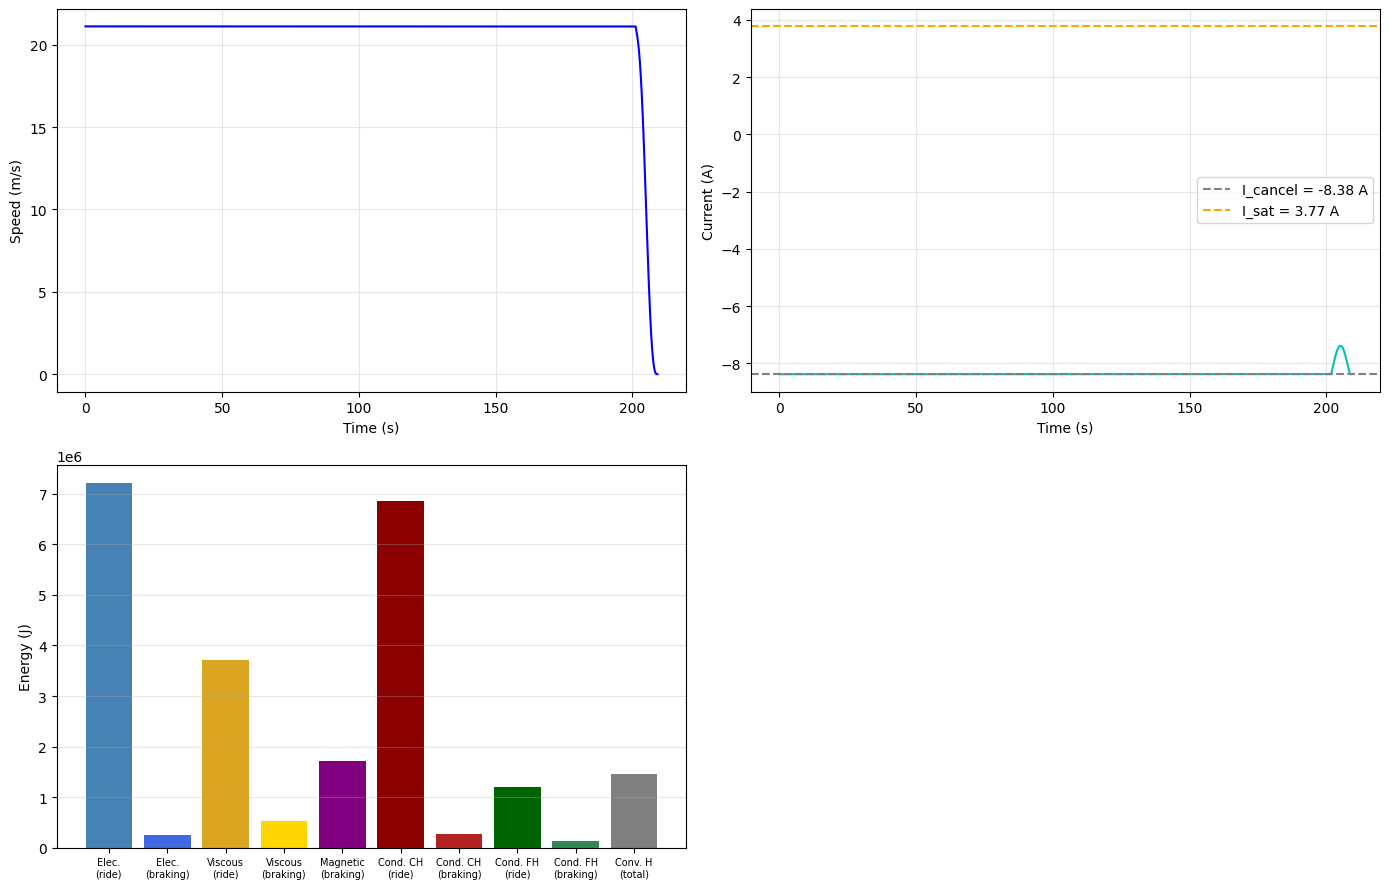

✓ Saved: OUTPUT/falcons_flight_temperatures.png


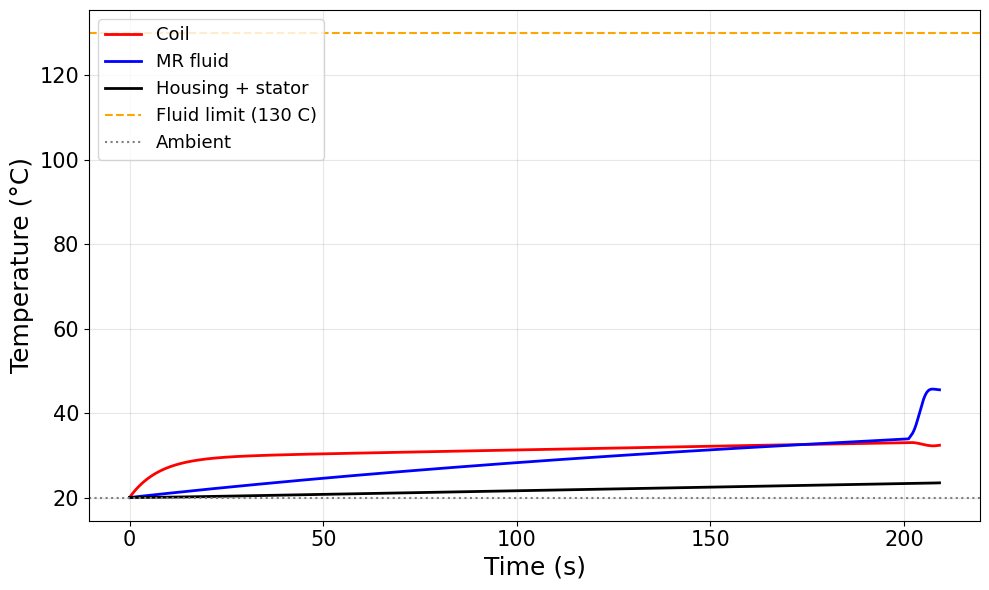

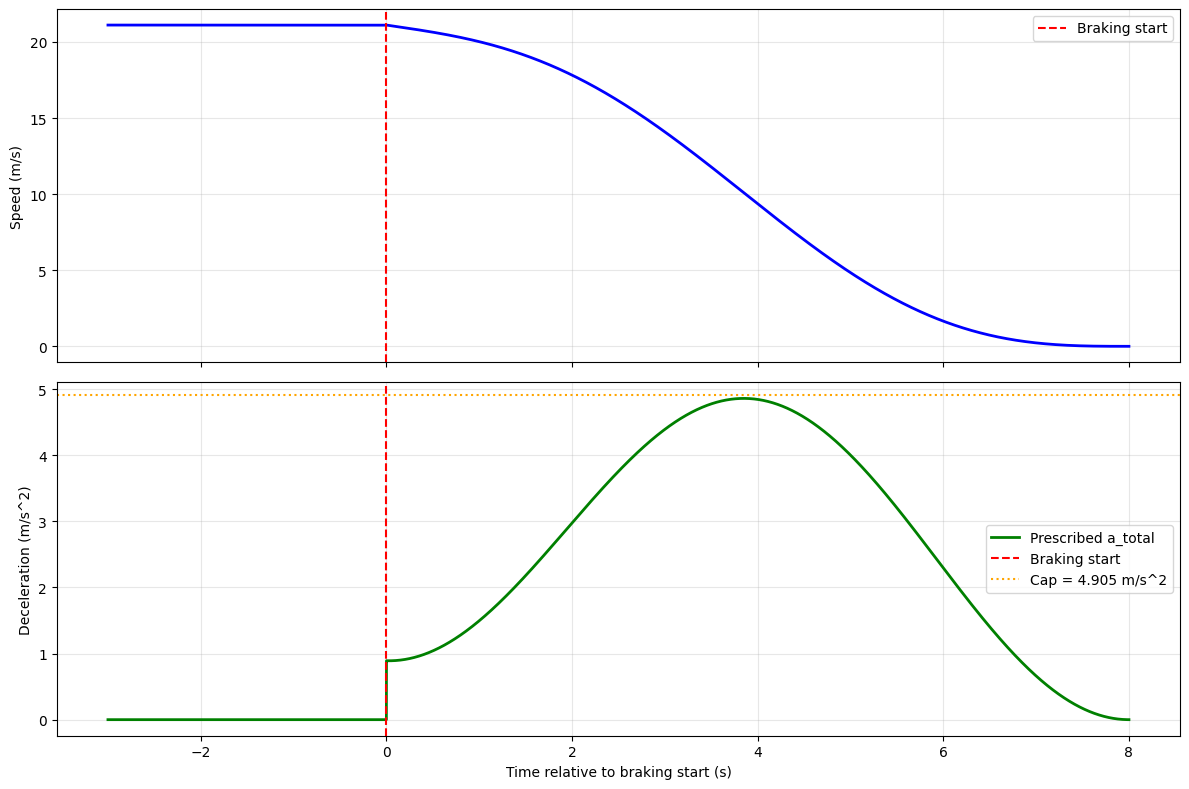

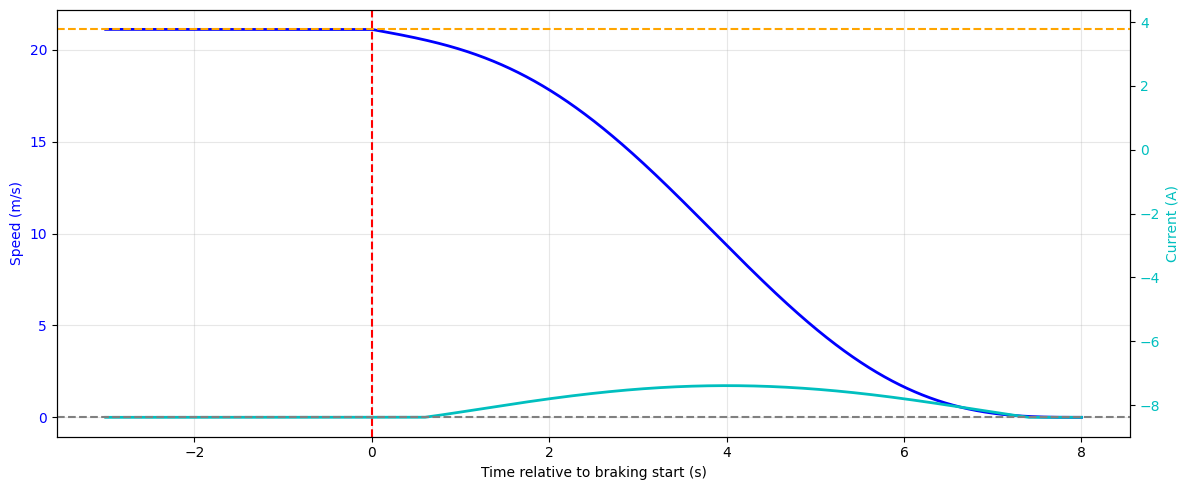


DONE


In [ ]:
"""
FALCON'S FLIGHT MR BRAKE: FULL RIDE + SEPARATE BRAKING EVENT
Braking deceleration = prescribed cosine bell + viscous floor

ORIGINAL VERSION:
  - No leakage factor and no recoil permeability corrections.
    B_PM_total = 2 * 0.4 T = 0.8 T.
  - Carrier fluid viscosity (0.011 Pa·s) used during the RIDE phase,
    consistent with the positive magnetophoresis assumption.
  - Full MR fluid viscosity (0.112 Pa·s) used during the BRAKING phase.
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =============================================================================
# RIDE PARAMETERS
# =============================================================================

v_cruise = 76 / 3.6
L_ride = 4325.0
m_train = 10000.0
R_wheel = 0.10

# =============================================================================
# BRAKE GEOMETRY AND FLUID
# =============================================================================

r_i = 0.05
r_o = 0.15
d = 0.005
m_discs = 120
n_unit = 2

mu_carrier = 0.011
mu_full = 0.112

rho = 3000
Cp_MR = 800

m_fluid_unit = n_unit * np.pi * (r_o**2 - r_i**2) * d * rho

# =============================================================================
# MAGNETIC CIRCUIT
# =============================================================================

B_PM_per_side = 0.4
B_PM_total = 2 * B_PM_per_side

N_turns = 100
mu_0 = 4 * np.pi * 1e-7
mu_r_MR = 3.798
B_sat = 1.16

I_cancel = -B_PM_total * d / (mu_0 * mu_r_MR * N_turns)
I_sat = (B_sat - B_PM_total) * d / (mu_0 * mu_r_MR * N_turns)

print("=" * 70)
print("MAGNETIC CIRCUIT")
print("=" * 70)
print(f"B_PM (total)              = {B_PM_total:.4f} T")
print(f"I_cancel                  = {I_cancel:.4f} A")
print(f"I_sat                     = {I_sat:.4f} A")
print()

# =============================================================================
# COIL
# =============================================================================

r_mean_coil = 0.10
AWG = 20
wire_diameter = 0.812e-3
wire_area = np.pi * (wire_diameter / 2)**2
rho_copper_20C = 1.68e-8
alpha_copper = 0.00393
n_coils_series = 2

l_wire_one_coil = 2 * np.pi * r_mean_coil * N_turns
R_unit_20C = n_coils_series * rho_copper_20C * l_wire_one_coil / wire_area

rho_copper_density = 8960.0
V_wire_one_unit = n_coils_series * l_wire_one_coil * wire_area
m_coil = rho_copper_density * V_wire_one_unit
Cp_copper = 385

# =============================================================================
# HOUSING + STATOR THERMAL MASS
# =============================================================================
rho_steel = 7850.0
r_housing_out = 0.18
r_housing_in = 0.17
L_housing = 0.22

V_tube = np.pi * (r_housing_out**2 - r_housing_in**2) * L_housing
V_caps = 2 * np.pi * (r_housing_out**2 - r_i**2) * (r_housing_out - r_housing_in)
V_housing = V_tube + V_caps
m_housing = rho_steel * V_housing
Cp_steel = 500.0
A_housing = 0.452

# =============================================================================
# THERMAL RESISTANCES
# =============================================================================
h_eff_coil_housing = 300.0
A_coil_surface = 0.102
R_CH = 1.0 / (h_eff_coil_housing * A_coil_surface)

k_F_eff = 0.319
h_gap = k_F_eff / d
A_fluid_surface = 0.126
R_FH = 1.0 / (h_gap * A_fluid_surface)

T_ambient = 20.0

# =============================================================================
# PHYSICS FUNCTIONS
# =============================================================================

def calculate_B(I):
    B_EM_total = (mu_0 * mu_r_MR * N_turns * I) / d
    B_raw = B_PM_total + B_EM_total
    return max(min(B_raw, B_sat), -B_sat)

def yield_stress_from_B(B):
    B_abs = abs(B)
    tau_y_kPa = 52.962*B_abs**4 - 176.51*B_abs**3 + 158.79*B_abs**2 + 13.708*B_abs + 0.1442
    return tau_y_kPa * 1000

def T_on_unit(I):
    tau_y = yield_stress_from_B(calculate_B(I))
    return (2*np.pi*n_unit*tau_y/3)*(r_o**3 - r_i**3)

def T_off_unit(omega, mu_fluid):
    return (np.pi*n_unit*mu_fluid*omega/(2*d))*(r_o**4 - r_i**4)

def T_on_total(I, m_discs):
    return m_discs * T_on_unit(I)

def T_off_total(omega, mu_fluid, m_discs):
    return m_discs * T_off_unit(omega, mu_fluid)

def T_total(I, omega, mu_fluid, m_discs):
    return T_on_total(I, m_discs) + T_off_total(omega, mu_fluid, m_discs)

def h_convection(v):
    v_abs = max(abs(v), 0.0)
    return 8.0 * (v_abs ** 0.75)

# =============================================================================
# BRAKING EVENT
# =============================================================================

a_cap = 0.5 * 9.81

def cosine_bell(t, t_brake):
    return 0.5 * (1.0 - np.cos(2.0 * np.pi * t / t_brake))

def simulate_braking_profile(t_brake, A, dt_sim=0.001):
    t = np.arange(0, t_brake + dt_sim, dt_sim)
    v = np.zeros_like(t)
    a_bell_arr = np.zeros_like(t)
    a_visc_arr = np.zeros_like(t)
    a_total_arr = np.zeros_like(t)
    x = np.zeros_like(t)
    v[0] = v_cruise

    for i in range(len(t)):
        omega = v[i] / R_wheel
        T_visc = T_off_total(omega, mu_full, m_discs)
        a_visc_arr[i] = T_visc / (m_train * R_wheel)
        a_bell_arr[i] = A * cosine_bell(t[i], t_brake)
        a_total_arr[i] = a_bell_arr[i] + a_visc_arr[i]
        if i < len(t) - 1:
            v[i+1] = max(0.0, v[i] - a_total_arr[i] * dt_sim)
            x[i+1] = x[i] + v[i+1] * dt_sim

    return t, v, a_bell_arr, a_visc_arr, a_total_arr, x

def solve_A_for_impulse(t_brake, A_init=1.0, dt_sim=0.002, n_iter=20):
    t_arr = np.arange(0, t_brake + dt_sim, dt_sim)
    bell_impulse_unit = np.trapz(cosine_bell(t_arr, t_brake), t_arr)
    if bell_impulse_unit <= 0:
        return None

    A = A_init
    for _ in range(n_iter):
        _, _, _, a_visc_arr, _, _ = simulate_braking_profile(t_brake, A, dt_sim)
        visc_impulse = np.trapz(a_visc_arr, t_arr)
        A_new = (v_cruise - visc_impulse) / bell_impulse_unit
        if abs(A_new - A) < 1e-8:
            return A_new
        A = A_new
    return A

# =============================================================================
# SOLVE FOR BRAKING PROFILE
# =============================================================================

t_brake_coarse = 1.0
A_coarse = None
while t_brake_coarse < 30.0:
    A_candidate = solve_A_for_impulse(t_brake_coarse, A_init=1.0, dt_sim=0.002)
    if A_candidate is None:
        t_brake_coarse += 0.20
        continue
    _, _, _, _, a_total_arr, _ = simulate_braking_profile(t_brake_coarse, A_candidate, 0.002)
    peak = np.max(a_total_arr)
    if peak <= a_cap:
        A_coarse = A_candidate
        break
    t_brake_coarse += 0.20

if A_coarse is None:
    raise SystemExit("Could not satisfy the 0.5g cap.")

t_brake = t_brake_coarse
A_brake = A_coarse
t_lo = max(1.0, t_brake_coarse - 0.20)
t_scan = t_lo
while t_scan < t_brake_coarse:
    A_candidate = solve_A_for_impulse(t_scan, A_init=A_brake, dt_sim=0.002)
    if A_candidate is not None:
        _, _, _, _, a_total_arr, _ = simulate_braking_profile(t_scan, A_candidate, 0.002)
        peak = np.max(a_total_arr)
        if peak <= a_cap:
            A_brake = A_candidate
            t_brake = t_scan
    t_scan += 0.01

t_bell, v_bell, a_bell, a_visc_bell, a_total_bell, x_bell = simulate_braking_profile(
    t_brake, A_brake, dt_sim=0.001)
L_brake = x_bell[-1]

print("=" * 70)
print("BRAKING PROFILE")
print("=" * 70)
print(f"t_brake           = {t_brake:.4f} s")
print(f"A_brake           = {A_brake:.4f} m/s^2 ({A_brake/9.81:.3f} g)")
print(f"Braking distance  = {L_brake:.4f} m")
print(f"T_on_unit at I_cancel = {T_on_unit(I_cancel):.4f} Nm")
print(f"T_on_unit at I_sat    = {T_on_unit(I_sat):,.1f} Nm")
print(f"T_on_total at I_sat   = {T_on_total(I_sat, m_discs):,.1f} Nm")

# =============================================================================
# SIMULATION
# =============================================================================

dt = 0.001
time = 0.0

T_coil = T_ambient
T_fluid = T_ambient
T_housing = T_ambient

time_arr = []
T_coil_arr = []
T_fluid_arr = []
T_housing_arr = []
I_arr = []
P_elec_unit_arr = []
P_cond_coil_housing_arr = []
P_cond_fluid_housing_arr = []
P_conv_housing_arr = []
P_fluid_visc_unit_arr = []
P_fluid_mag_unit_arr = []
h_arr = []
phase_arr = []
speed_arr = []
decel_arr = []

# --- RIDE PHASE ---
L_ride_phase = L_ride - L_brake
t_ride_phase = L_ride_phase / v_cruise

omega = v_cruise / R_wheel

while time < t_ride_phase:
    I_now = I_cancel

    v_now = omega * R_wheel
    h_now = h_convection(v_now)

    rho_copper = rho_copper_20C * (1 + alpha_copper * (T_coil - 20.0))
    R_now = n_coils_series * rho_copper * l_wire_one_coil / wire_area
    P_elec_unit = I_now**2 * R_now

    P_cond_CH_unit = (T_coil - T_housing) / R_CH
    P_cond_FH_unit = (T_fluid - T_housing) / R_FH
    P_conv_H_unit = h_now * A_housing * (T_housing - T_ambient)

    T_off_unit_now = T_off_unit(omega, mu_carrier)
    P_visc_unit = T_off_unit_now * omega
    P_mag_unit = 0.0
    P_fluid_unit = P_visc_unit

    dT_coil = (P_elec_unit - P_cond_CH_unit) * dt / (m_coil * Cp_copper)
    dT_fluid = (P_fluid_unit - P_cond_FH_unit) * dt / (m_fluid_unit * Cp_MR)
    dT_housing = (P_cond_CH_unit + P_cond_FH_unit - P_conv_H_unit) * dt \
                 / (m_housing * Cp_steel)

    T_coil += dT_coil
    T_fluid += dT_fluid
    T_housing += dT_housing
    time += dt

    time_arr.append(time)
    T_coil_arr.append(T_coil)
    T_fluid_arr.append(T_fluid)
    T_housing_arr.append(T_housing)
    I_arr.append(I_now)
    P_elec_unit_arr.append(P_elec_unit)
    P_cond_coil_housing_arr.append(P_cond_CH_unit)
    P_cond_fluid_housing_arr.append(P_cond_FH_unit)
    P_conv_housing_arr.append(P_conv_H_unit)
    P_fluid_visc_unit_arr.append(P_visc_unit)
    P_fluid_mag_unit_arr.append(P_mag_unit)
    h_arr.append(h_now)
    phase_arr.append("ride")
    speed_arr.append(v_now)
    decel_arr.append(0.0)

print(f"\nRide complete. Coil: {T_coil:.2f} C, Fluid: {T_fluid:.2f} C, "
      f"Housing: {T_housing:.2f} C")

# --- BRAKING PHASE ---
omega = v_cruise / R_wheel
speed_prev = v_cruise

for i in range(len(t_bell)):
    a_total_now = a_total_bell[i]

    T_req_total = m_train * R_wheel * a_total_now
    T_off_now_total = T_off_total(omega, mu_full, m_discs)
    T_on_req_total = max(T_req_total - T_off_now_total, 0.0)
    T_on_req_unit = T_on_req_total / m_discs

    if T_on_req_unit < 1e-9:
        I_now = I_cancel
    else:
        I_lo, I_hi = I_cancel, I_sat
        for _ in range(60):
            I_mid = 0.5 * (I_lo + I_hi)
            if T_on_unit(I_mid) > T_on_req_unit:
                I_hi = I_mid
            else:
                I_lo = I_mid
        I_now = 0.5 * (I_lo + I_hi)

    v_now = omega * R_wheel
    h_now = h_convection(v_now)

    rho_copper = rho_copper_20C * (1 + alpha_copper * (T_coil - 20.0))
    R_now = n_coils_series * rho_copper * l_wire_one_coil / wire_area
    P_elec_unit = I_now**2 * R_now

    P_cond_CH_unit = (T_coil - T_housing) / R_CH
    P_cond_FH_unit = (T_fluid - T_housing) / R_FH
    P_conv_H_unit = h_now * A_housing * (T_housing - T_ambient)

    T_on_unit_now = T_on_unit(I_now)
    T_off_unit_now = T_off_unit(omega, mu_full)
    P_visc_unit = T_off_unit_now * omega
    P_mag_unit = T_on_unit_now * omega
    P_fluid_unit = P_visc_unit + P_mag_unit

    dT_coil = (P_elec_unit - P_cond_CH_unit) * dt / (m_coil * Cp_copper)
    dT_fluid = (P_fluid_unit - P_cond_FH_unit) * dt / (m_fluid_unit * Cp_MR)
    dT_housing = (P_cond_CH_unit + P_cond_FH_unit - P_conv_H_unit) * dt \
                 / (m_housing * Cp_steel)

    T_coil += dT_coil
    T_fluid += dT_fluid
    T_housing += dT_housing

    v_new = v_bell[i]
    omega = v_new / R_wheel
    a_actual = a_total_now
    speed_prev = v_new

    time += dt
    time_arr.append(time)
    T_coil_arr.append(T_coil)
    T_fluid_arr.append(T_fluid)
    T_housing_arr.append(T_housing)
    I_arr.append(I_now)
    P_elec_unit_arr.append(P_elec_unit)
    P_cond_coil_housing_arr.append(P_cond_CH_unit)
    P_cond_fluid_housing_arr.append(P_cond_FH_unit)
    P_conv_housing_arr.append(P_conv_H_unit)
    P_fluid_visc_unit_arr.append(P_visc_unit)
    P_fluid_mag_unit_arr.append(P_mag_unit)
    h_arr.append(h_now)
    phase_arr.append("braking")
    speed_arr.append(v_new)
    decel_arr.append(a_actual)

# =============================================================================
# ENERGY INTEGRALS
# =============================================================================

time_arr = np.array(time_arr)
T_coil_arr = np.array(T_coil_arr)
T_fluid_arr = np.array(T_fluid_arr)
T_housing_arr = np.array(T_housing_arr)
I_arr = np.array(I_arr)
P_elec_unit_arr = np.array(P_elec_unit_arr)
P_cond_coil_housing_arr = np.array(P_cond_coil_housing_arr)
P_cond_fluid_housing_arr = np.array(P_cond_fluid_housing_arr)
P_conv_housing_arr = np.array(P_conv_housing_arr)
P_fluid_visc_unit_arr = np.array(P_fluid_visc_unit_arr)
P_fluid_mag_unit_arr = np.array(P_fluid_mag_unit_arr)
h_arr = np.array(h_arr)
phase_arr = np.array(phase_arr)
speed_arr = np.array(speed_arr)
decel_arr = np.array(decel_arr)

ride_mask = phase_arr == "ride"
brake_mask = phase_arr == "braking"

E_elec_ride_unit = np.trapz(P_elec_unit_arr[ride_mask], time_arr[ride_mask])
E_elec_brake_unit = np.trapz(P_elec_unit_arr[brake_mask], time_arr[brake_mask])
E_elec_total_unit = E_elec_ride_unit + E_elec_brake_unit

E_cond_CH_ride_unit = np.trapz(P_cond_coil_housing_arr[ride_mask], time_arr[ride_mask])
E_cond_CH_brake_unit = np.trapz(P_cond_coil_housing_arr[brake_mask], time_arr[brake_mask])
E_cond_CH_total_unit = E_cond_CH_ride_unit + E_cond_CH_brake_unit

E_cond_FH_ride_unit = np.trapz(P_cond_fluid_housing_arr[ride_mask], time_arr[ride_mask])
E_cond_FH_brake_unit = np.trapz(P_cond_fluid_housing_arr[brake_mask], time_arr[brake_mask])
E_cond_FH_total_unit = E_cond_FH_ride_unit + E_cond_FH_brake_unit

E_conv_H_ride_unit = np.trapz(P_conv_housing_arr[ride_mask], time_arr[ride_mask])
E_conv_H_brake_unit = np.trapz(P_conv_housing_arr[brake_mask], time_arr[brake_mask])
E_conv_H_total_unit = E_conv_H_ride_unit + E_conv_H_brake_unit

E_fluid_visc_ride_unit = np.trapz(P_fluid_visc_unit_arr[ride_mask], time_arr[ride_mask])
E_fluid_visc_brake_unit = np.trapz(P_fluid_visc_unit_arr[brake_mask], time_arr[brake_mask])
E_fluid_visc_total_unit = E_fluid_visc_ride_unit + E_fluid_visc_brake_unit

E_fluid_mag_brake_unit = np.trapz(P_fluid_mag_unit_arr[brake_mask], time_arr[brake_mask])
E_fluid_mag_ride_unit = 0.0
E_fluid_mag_total_unit = E_fluid_mag_ride_unit + E_fluid_mag_brake_unit

E_fluid_total_unit = E_fluid_visc_total_unit + E_fluid_mag_total_unit

E_elec_ride = E_elec_ride_unit * m_discs
E_elec_brake = E_elec_brake_unit * m_discs
E_elec_total = E_elec_total_unit * m_discs

E_cond_CH_ride = E_cond_CH_ride_unit * m_discs
E_cond_CH_brake = E_cond_CH_brake_unit * m_discs
E_cond_CH_total = E_cond_CH_total_unit * m_discs

E_cond_FH_ride = E_cond_FH_ride_unit * m_discs
E_cond_FH_brake = E_cond_FH_brake_unit * m_discs
E_cond_FH_total = E_cond_FH_total_unit * m_discs

E_conv_H_ride = E_conv_H_ride_unit * m_discs
E_conv_H_brake = E_conv_H_brake_unit * m_discs
E_conv_H_total = E_conv_H_total_unit * m_discs

E_fluid_visc_ride = E_fluid_visc_ride_unit * m_discs
E_fluid_visc_brake = E_fluid_visc_brake_unit * m_discs
E_fluid_visc_total = E_fluid_visc_total_unit * m_discs

E_fluid_mag_ride = E_fluid_mag_ride_unit * m_discs
E_fluid_mag_brake = E_fluid_mag_brake_unit * m_discs
E_fluid_mag_total = E_fluid_mag_total_unit * m_discs

E_fluid_ride = E_fluid_visc_ride + E_fluid_mag_ride
E_fluid_brake = E_fluid_visc_brake + E_fluid_mag_brake
E_fluid_total = E_fluid_ride + E_fluid_brake

E_kinetic = 0.5 * m_train * v_cruise**2

# =============================================================================
# REPORT
# =============================================================================

print("\n" + "=" * 70)
print("RESULTS")
print("=" * 70)

print(f"\n--- MAGNETIC PARAMETERS ---")
print(f"B_PM (total)              = {B_PM_total:.4f} T")
print(f"I_cancel                  = {I_cancel:.4f} A")
print(f"I_sat                     = {I_sat:.4f} A")
print(f"T_on_unit at I_sat        = {T_on_unit(I_sat):,.1f} Nm")
print(f"T_on_total at I_sat       = {T_on_total(I_sat, m_discs):,.1f} Nm")

print(f"\n--- COIL THERMAL MASS (PER UNIT) ---")
print(f"Wire gauge:                    AWG {AWG}")
print(f"Wire volume per unit:          {V_wire_one_unit:.3e} m^3")
print(f"Copper density:                {rho_copper_density:.0f} kg/m^3")
print(f"m_coil = rho * V_wire:         {m_coil:.4f} kg")
print(f"MR fluid mass per unit:        {m_fluid_unit:.4f} kg")
print(f"Housing mass per unit:         {m_housing:.2f} kg")
print(f"Number of units (m_discs):     {m_discs}")

print(f"\n--- ELECTRICAL ENERGY (TOTAL, x {m_discs}) ---")
print(f"Ride phase (I_cancel):         {E_elec_ride:,.1f} J  ({E_elec_ride/1e6:.2f} MJ)")
print(f"Braking phase:                 {E_elec_brake:,.1f} J  ({E_elec_brake/1e6:.2f} MJ)")
print(f"Total:                         {E_elec_total:,.1f} J  ({E_elec_total/1e6:.2f} MJ)")

print(f"\n--- VISCOUS DISSIPATION (TOTAL, x {m_discs}) ---")
print(f"Ride phase (mu_carrier):       {E_fluid_visc_ride:,.1f} J  ({E_fluid_visc_ride/1e6:.2f} MJ)")
print(f"Braking phase (mu_full):       {E_fluid_visc_brake:,.1f} J  ({E_fluid_visc_brake/1e6:.2f} MJ)")
print(f"Whole ride (ride + braking):   {E_fluid_visc_total:,.1f} J  ({E_fluid_visc_total/1e6:.2f} MJ)")

print(f"\n--- MAGNETIC DISSIPATION (TOTAL, x {m_discs}) ---")
print(f"Ride phase:                    {E_fluid_mag_ride:,.1f} J  (zero by construction)")
print(f"Braking phase:                 {E_fluid_mag_brake:,.1f} J  ({E_fluid_mag_brake/1e6:.2f} MJ)")
print(f"Whole ride:                    {E_fluid_mag_total:,.1f} J  ({E_fluid_mag_total/1e6:.2f} MJ)")

print(f"\n--- TOTAL FLUID DISSIPATION (TOTAL, x {m_discs}) ---")
print(f"Ride phase:                    {E_fluid_ride:,.1f} J  ({E_fluid_ride/1e6:.2f} MJ)")
print(f"Braking phase:                 {E_fluid_brake:,.1f} J  ({E_fluid_brake/1e6:.2f} MJ)")
print(f"Grand total:                   {E_fluid_total:,.1f} J  ({E_fluid_total/1e6:.2f} MJ)")

print(f"\n--- HEAT FLOW ENERGY (TOTAL, x {m_discs}) ---")
print(f"Coil->housing (ride):          {E_cond_CH_ride:,.1f} J  ({E_cond_CH_ride/1e6:.2f} MJ)")
print(f"Coil->housing (braking):       {E_cond_CH_brake:,.1f} J  ({E_cond_CH_brake/1e6:.2f} MJ)")
print(f"Fluid->housing (ride):         {E_cond_FH_ride:,.1f} J  ({E_cond_FH_ride/1e6:.2f} MJ)")
print(f"Fluid->housing (braking):      {E_cond_FH_brake:,.1f} J  ({E_cond_FH_brake/1e6:.2f} MJ)")
print(f"Housing->air (ride):           {E_conv_H_ride:,.1f} J  ({E_conv_H_ride/1e6:.2f} MJ)")
print(f"Housing->air (braking):        {E_conv_H_brake:,.1f} J  ({E_conv_H_brake/1e6:.2f} MJ)")
print(f"Housing->air (total):          {E_conv_H_total:,.1f} J  ({E_conv_H_total/1e6:.2f} MJ)")

print(f"\n--- KINETIC ENERGY ---")
print(f"E_kinetic = 0.5 * m * v^2 =   {E_kinetic:,.1f} J  ({E_kinetic/1000:.1f} kJ)")

print(f"\n--- TEMPERATURES (THREE-NODE) ---")
print(f"Coil    end of ride:           {T_coil_arr[ride_mask][-1]:.2f} C")
print(f"Coil    end of braking:        {T_coil_arr[-1]:.2f} C")
print(f"Fluid   end of ride:           {T_fluid_arr[ride_mask][-1]:.2f} C")
print(f"Fluid   end of braking:        {T_fluid_arr[-1]:.2f} C")
print(f"Housing end of ride:           {T_housing_arr[ride_mask][-1]:.2f} C")
print(f"Housing end of braking:        {T_housing_arr[-1]:.2f} C")

print(f"\n--- PEAK TEMPERATURES ---")
print(f"Peak coil:                     {T_coil_arr.max():.2f} C")
print(f"Peak MR fluid:                 {T_fluid_arr.max():.2f} C")
print(f"Peak housing:                  {T_housing_arr.max():.2f} C")

print(f"\n--- CURRENT RANGE USED ---")
print(f"Min current during braking:    {I_arr[brake_mask].min():.4f} A")
print(f"Max current during braking:    {I_arr[brake_mask].max():.4f} A")

print(f"\n--- FEASIBILITY CHECK ---")
if T_fluid_arr.max() < 130.0:
    print(f"PASS: MR fluid peak ({T_fluid_arr.max():.1f} C) < 130 C limit")
else:
    print(f"FAIL: MR fluid peak ({T_fluid_arr.max():.1f} C) > 130 C limit")

# =============================================================================
# ZOOMED DATA AND PLOTS
# =============================================================================

brake_start_time = t_ride_phase
zoom_start_time = max(0.0, brake_start_time - 3.0)

zoom_mask = time_arr >= zoom_start_time
zoom_time = time_arr[zoom_mask] - brake_start_time
zoom_speed = speed_arr[zoom_mask]
zoom_decel = decel_arr[zoom_mask]
zoom_I = I_arr[zoom_mask]

OUTPUT_DIR = Path("OUTPUT")
OUTPUT_DIR.mkdir(exist_ok=True)

FIG_SIZE = (10, 6)

# --- FIGURE 1: 2x2 overview (not saved) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(time_arr, speed_arr, 'b-', linewidth=1.5)
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Speed (m/s)')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(time_arr, I_arr, 'c-', linewidth=1.5)
axes[0, 1].axhline(y=I_cancel, color='gray', linestyle='--',
                   label=f'I_cancel = {I_cancel:.2f} A')
axes[0, 1].axhline(y=I_sat, color='orange', linestyle='--',
                   label=f'I_sat = {I_sat:.2f} A')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Current (A)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

axes[1, 0].bar(['Elec.\n(ride)', 'Elec.\n(braking)',
                'Viscous\n(ride)', 'Viscous\n(braking)',
                'Magnetic\n(braking)',
                'Cond. CH\n(ride)', 'Cond. CH\n(braking)',
                'Cond. FH\n(ride)', 'Cond. FH\n(braking)',
                'Conv. H\n(total)'],
               [E_elec_ride, E_elec_brake,
                E_fluid_visc_ride, E_fluid_visc_brake,
                E_fluid_mag_brake,
                E_cond_CH_ride, E_cond_CH_brake,
                E_cond_FH_ride, E_cond_FH_brake,
                E_conv_H_total],
               color=['steelblue', 'royalblue',
                      'goldenrod', 'gold',
                      'purple',
                      'darkred', 'firebrick',
                      'darkgreen', 'seagreen',
                      'gray'])
axes[1, 0].set_ylabel('Energy (J)')
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].tick_params(axis='x', labelsize=7)

axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# --- FIGURE 2: Three-node temperature plot (SAVED) ---
fig, ax = plt.subplots(figsize=FIG_SIZE)

ax.plot(time_arr, T_coil_arr, 'r-', linewidth=2, label='Coil')
ax.plot(time_arr, T_fluid_arr, 'b-', linewidth=2, label='MR fluid')
ax.plot(time_arr, T_housing_arr, 'k-', linewidth=2, label='Housing + stator')
ax.axhline(y=130.0, color='orange', linestyle='--', label='Fluid limit (130 C)')
ax.axhline(y=T_ambient, color='gray', linestyle=':', label='Ambient')
ax.set_xlabel('Time (s)', fontsize=18)
ax.set_ylabel('Temperature (°C)', fontsize=18)
ax.tick_params(axis='both', labelsize=15)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=13)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "falcons_flight_temperatures.png", dpi=800, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_DIR / 'falcons_flight_temperatures.png'}")
plt.show()

# --- FIGURE 3: Zoomed speed and deceleration (not saved) ---
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(zoom_time, zoom_speed, 'b-', linewidth=2)
axes[0].axvline(x=0.0, color='red', linestyle='--', label='Braking start')
axes[0].set_ylabel('Speed (m/s)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(zoom_time, zoom_decel, 'g-', linewidth=2, label='Prescribed a_total')
axes[1].axvline(x=0.0, color='red', linestyle='--', label='Braking start')
axes[1].axhline(y=a_cap, color='orange', linestyle=':', label=f'Cap = {a_cap:.3f} m/s^2')
axes[1].set_xlabel('Time relative to braking start (s)')
axes[1].set_ylabel('Deceleration (m/s^2)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# --- FIGURE 4: Zoomed speed and current (not saved) ---
fig, ax1 = plt.subplots(figsize=(12, 5))

color1 = 'b'
ax1.set_xlabel('Time relative to braking start (s)')
ax1.set_ylabel('Speed (m/s)', color=color1)
ax1.plot(zoom_time, zoom_speed, color=color1, linewidth=2, label='Speed')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color2 = 'c'
ax2.set_ylabel('Current (A)', color=color2)
ax2.plot(zoom_time, zoom_I, color=color2, linewidth=2, label='Current')
ax2.axhline(y=I_cancel, color='gray', linestyle='--', label=f'I_cancel = {I_cancel:.2f} A')
ax2.axhline(y=I_sat, color='orange', linestyle='--', label=f'I_sat = {I_sat:.2f} A')
ax2.tick_params(axis='y', labelcolor=color2)

ax1.axvline(x=0.0, color='red', linestyle='--', label='Braking start')
fig.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("DONE")
print("=" * 70)

Fail-Safe Testing

MAGNETIC CIRCUIT
B_PM (raw, total)         = 0.1000 T
I_cancel                  = -1.0476 A

FAIL-SAFE BRAKE AT I = 0 (POWER LOSS)
B_PM_total                = 0.1000 T
Dynamic yield stress      = 2.93 kPa
Static  yield stress      = 2.93 kPa  (conservative k = 1.00)
Dynamic torque T_on(0)    = 13,171 Nm
Static  holding torque    = 13,171 Nm
Fluid mass (total)        = 622.0 kg
Fluid mass (per unit)     = 1.8850 kg
Fluid thermal capacity (per unit) = 1.51 kJ/K

--- CAMELBACK KINEMATICS (conservation of energy) ---
Base speed (250 km/h)     = 69.4 m/s
Halfway (h = 82.5 m)      = 56.6 m/s = 204 km/h
Top     (h = 165  m)      = 39.8 m/s = 143 km/h

PHASE 1: DYNAMIC STOP AT I = 0 (fail-safe braking)

1. LSM lift hill
  Speed:        40 km/h (11.1 m/s)
  Incline:      45 deg
  Direction:    uphill
  Peak decel.:  21.40 m/s^2 (2.18 g)
  Avg  decel.:  20.75 m/s^2 (2.11 g)
  Stop time:    535.6 ms
  Stop distance:2.94 m
  Energy diss.: 0.41 MJ
  Fluid dT:     0.8 deg C
  Fluid final:  20.8 deg 

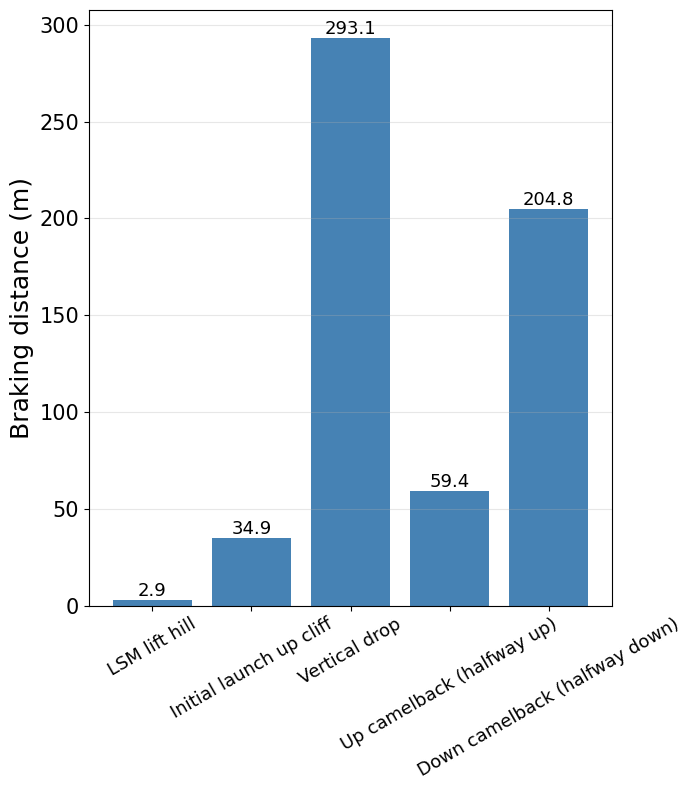

✓ Saved: OUTPUT/failsafe_peak_deceleration.png


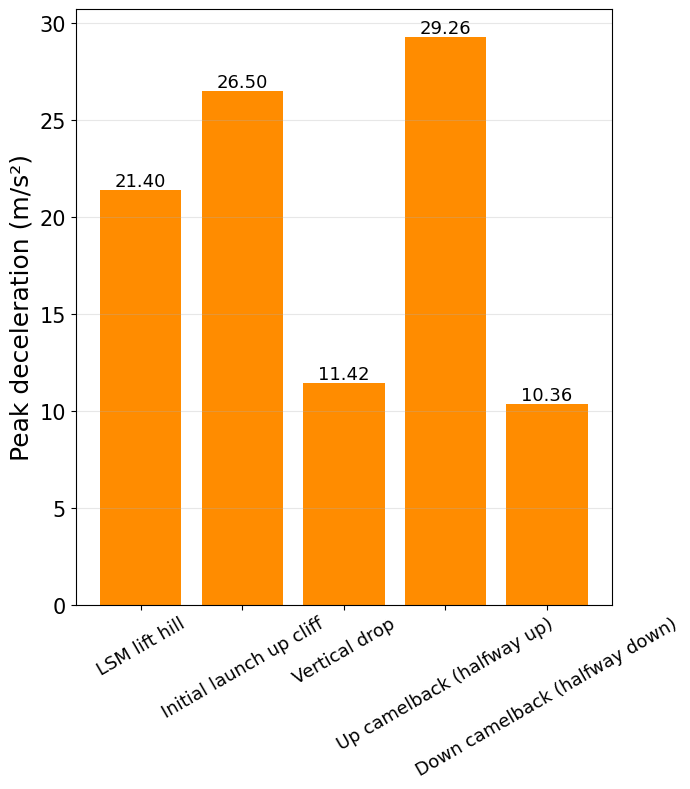

✓ Saved: OUTPUT/failsafe_fluid_temperature.png


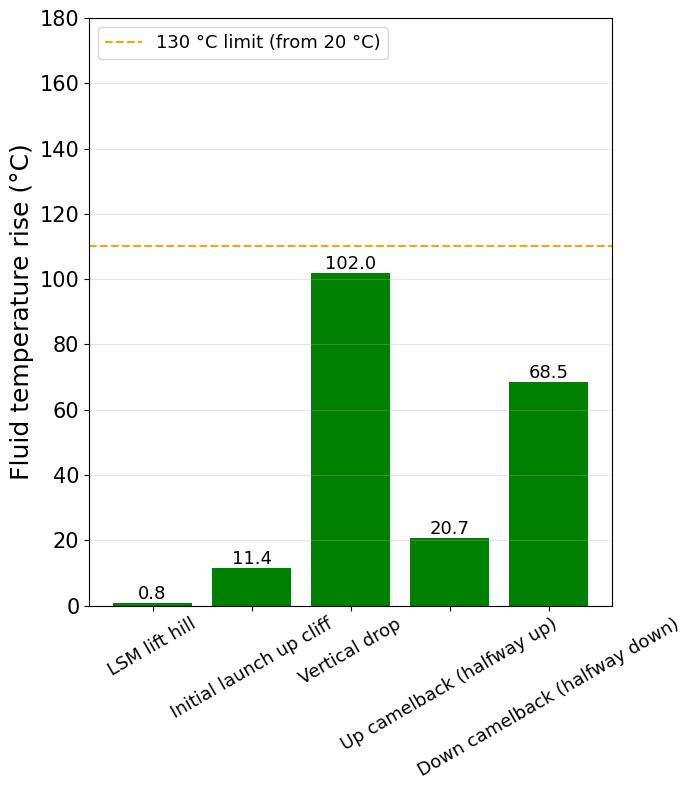

✓ Saved: OUTPUT/failsafe_holding_margin.png


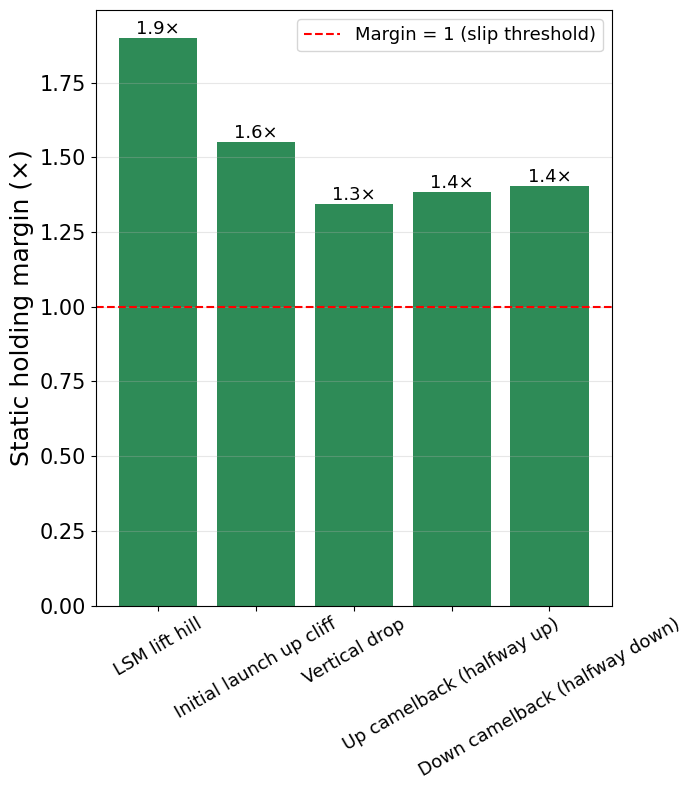

In [ ]:
"""
FALCON'S FLIGHT MR BRAKE: FAIL-SAFE STOP + STATIC HOLD ANALYSIS
Two-phase analysis:
  Phase 1 (Dynamic): Power lost -> I=0 -> brake decelerates train
                     using DYNAMIC yield stress from Parlak polynomial
  Phase 2 (Static):  Train at rest -> brake must HOLD against gravity
                     using STATIC yield stress (conservative: k = 1.0,
                     i.e. tau_sy = tau_dy, a lower bound)

Camelback speeds derived from conservation of energy:
  v(h) = sqrt(v_base^2 - 2*g*h)
  v_base = 250 km/h = 69.4 m/s at the base of the camelback
  At h = 82.5 m (halfway up):  v = 56.5 m/s = 203 km/h

Scenario table (updated):
  Scenario                       Speed (km/h)  Incline (deg)  Direction
  LSM Lift Hill                  40            45             Uphill
  Initial Launch up Cliff        150           60             Uphill
  Vertical Drop                  250           90             Downhill
  Up Camelback (halfway up)      203           76             Uphill
  Down Camelback (halfway down)  203           73             Downhill

Corrected magnetic circuit: two coils and two gaps, so the 2s cancel and
B_EM = mu_0 * mu_r_MR * N * I / d (no extra factor of 2).

Torque convention (n = number of fluid gaps = 2 * m_discs):
  T_on  = (2 pi n / 3) tau_y (r_o^3 - r_i^3)
  T_off = (pi n mu omega / (2 d)) (r_o^4 - r_i^4)

THERMAL MODEL (THREE-NODE, PER UNIT):
  Coil:     heats from Joule heating (I^2 R), cools by conduction to housing.
  Fluid:    heats from mechanical work on the fluid, cools by conduction
            across the MR gap into the housing/stator.
  Housing:  receives heat from coil and fluid, loses heat to air by convection.

  R_CH = 1 / (h_eff * A_C)
    h_eff = 300 W m^-2 K^-1, A_C = 0.102 m^2
  R_FH = 1 / (h_gap * A_fluid)
    k_F_eff = 0.319 W m^-1 K^-1, h_gap = k_F_eff / d = 63.8 W m^-2 K^-1
    A_fluid = 0.126 m^2
  Housing: closed steel cylinder, r_out = 0.18 m, L = 0.22 m, wall = 10 mm
           -> m_H = 33.8 kg, A_H = 0.452 m^2

  All thermal ODEs are PER UNIT (one disc, two coils, two MR gaps).
  P_fluid_unit = P_brake / m_discs
  m_fluid_unit = 2 * pi * (r_o^2 - r_i^2) * d * rho

Deceleration reported in each scenario:
  - PEAK (initial) deceleration: T_off decreases with omega, T_on is
    constant, so the largest deceleration occurs at t = 0.
  - AVERAGE deceleration: v0 / t_stop over the whole stop.
Both are printed, but only peak deceleration appears in the bar chart.
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =============================================================================
# TRAIN / RIDE PARAMETERS
# =============================================================================

m_train = 10000.0        # kg
R_wheel = 0.10           # m
g = 9.81                 # m/s^2

# =============================================================================
# BRAKE GEOMETRY AND FLUID
# =============================================================================

r_i = 0.05
r_o = 0.15
d = 0.005
m_discs = 330
n = 2 * m_discs

mu_full = 0.112          # Pa.s (field ON, braking)
rho = 3000               # kg/m^3
Cp_MR = 800              # J/(kg.K)

m_fluid_total = n * np.pi * (r_o**2 - r_i**2) * d * rho
m_fluid_unit  = 2 * np.pi * (r_o**2 - r_i**2) * d * rho

# =============================================================================
# MAGNETIC CIRCUIT
# =============================================================================

B_PM_per_side = 0.05
B_PM_total = 2 * B_PM_per_side      # = 0.8 T

N_turns = 100
mu_0 = 4 * np.pi * 1e-7
mu_r_MR = 3.798
B_sat = 1.0

I_cancel = -B_PM_total * d / (mu_0 * mu_r_MR * N_turns)

print("=" * 75)
print("MAGNETIC CIRCUIT")
print("=" * 75)
print(f"B_PM (raw, total)         = {B_PM_total:.4f} T")
print(f"I_cancel                  = {I_cancel:.4f} A")
print()

# =============================================================================
# THERMAL PARAMETERS (THREE-NODE MODEL, PER UNIT)
# =============================================================================

# Coil
r_mean_coil = 0.10
wire_diameter = 0.644e-3    # AWG 22
wire_area = np.pi * (wire_diameter / 2)**2
rho_copper_20C = 1.68e-8
alpha_copper = 0.00393
n_coils_per_unit = 2
l_wire_one_coil = 2 * np.pi * r_mean_coil * N_turns
rho_copper_density = 8960.0
V_wire_one_unit = n_coils_per_unit * l_wire_one_coil * wire_area
m_coil = rho_copper_density * V_wire_one_unit
Cp_copper = 385.0

# Housing (per unit)
rho_steel = 7850.0
r_housing_out = 0.18
r_housing_in = 0.17
L_housing = 0.22
V_tube = np.pi * (r_housing_out**2 - r_housing_in**2) * L_housing
V_caps = 2 * np.pi * (r_housing_out**2 - r_i**2) * (r_housing_out - r_housing_in)
V_housing = V_tube + V_caps
m_housing = rho_steel * V_housing
Cp_steel = 500.0
A_housing = 0.452

# Thermal resistances (per unit)
h_eff_coil_housing = 300.0
A_coil_surface = 0.102
R_CH = 1.0 / (h_eff_coil_housing * A_coil_surface)

k_F_eff = 0.319
h_gap = k_F_eff / d
A_fluid_surface = 0.126
R_FH = 1.0 / (h_gap * A_fluid_surface)

T_ambient = 20.0

# =============================================================================
# PHYSICS FUNCTIONS
# =============================================================================

def calculate_B(I):
    B_EM_total = (mu_0 * mu_r_MR * N_turns * I) / d
    B_raw = B_PM_total + B_EM_total
    return max(min(B_raw, B_sat), -B_sat)

def yield_stress_dynamic(B):
    B_abs = abs(B)
    tau_y_kPa = (52.962*B_abs**4 - 176.51*B_abs**3
                 + 158.79*B_abs**2 + 13.708*B_abs + 0.1442)
    return tau_y_kPa * 1000

def T_on(I):
    tau_y = yield_stress_dynamic(calculate_B(I))
    return (2*np.pi*n*tau_y/3)*(r_o**3 - r_i**3)

def T_off(omega, mu_fluid):
    return (np.pi*n*mu_fluid*omega/(2*d))*(r_o**4 - r_i**4)

def h_convection(v):
    v_abs = max(abs(v), 0.0)
    return 8.0 * (v_abs ** 0.75)

# =============================================================================
# FAIL-SAFE TORQUE AT I = 0
# =============================================================================

B_failsafe = B_PM_total
tau_y_dyn_failsafe = yield_stress_dynamic(B_failsafe)
T_on_failsafe = T_on(0.0)

k_static = 1.0
tau_y_static_failsafe = k_static * tau_y_dyn_failsafe
T_static_failsafe = (2*np.pi*n*tau_y_static_failsafe/3)*(r_o**3 - r_i**3)

print("=" * 75)
print("FAIL-SAFE BRAKE AT I = 0 (POWER LOSS)")
print("=" * 75)
print(f"B_PM_total                = {B_failsafe:.4f} T")
print(f"Dynamic yield stress      = {tau_y_dyn_failsafe/1000:.2f} kPa")
print(f"Static  yield stress      = {tau_y_static_failsafe/1000:.2f} kPa"
      f"  (conservative k = {k_static:.2f})")
print(f"Dynamic torque T_on(0)    = {T_on_failsafe:,.0f} Nm")
print(f"Static  holding torque    = {T_static_failsafe:,.0f} Nm")
print(f"Fluid mass (total)        = {m_fluid_total:.1f} kg")
print(f"Fluid mass (per unit)     = {m_fluid_unit:.4f} kg")
print(f"Fluid thermal capacity (per unit) = {m_fluid_unit*Cp_MR/1000:.2f} kJ/K")

# =============================================================================
# CAMELBACK SPEED FROM CONSERVATION OF ENERGY
# =============================================================================

v_base_camelback = 250 / 3.6
h_camelback = 165.0
h_halfway = h_camelback / 2.0

v_halfway = np.sqrt(max(v_base_camelback**2 - 2*g*h_halfway, 0.0))
v_top     = np.sqrt(max(v_base_camelback**2 - 2*g*h_camelback, 0.0))
v_halfway_kmh = v_halfway * 3.6
v_top_kmh     = v_top * 3.6

print(f"\n--- CAMELBACK KINEMATICS (conservation of energy) ---")
print(f"Base speed (250 km/h)     = {v_base_camelback:.1f} m/s")
print(f"Halfway (h = 82.5 m)      = {v_halfway:.1f} m/s = {v_halfway_kmh:.0f} km/h")
print(f"Top     (h = 165  m)      = {v_top:.1f} m/s = {v_top_kmh:.0f} km/h")

# =============================================================================
# SCENARIOS
# =============================================================================

scenarios = [
    ("1. LSM lift hill",                  40,   45, +1),
    ("2. Initial launch up cliff",       150,   60, +1),
    ("3. Vertical drop",                 250,   90, -1),
    ("4. Up camelback (halfway up)",     v_halfway_kmh, 76, +1),
    ("5. Down camelback (halfway down)", v_halfway_kmh, 73, -1),
]

# =============================================================================
# DYNAMIC STOP SIMULATION (I = 0) WITH THREE-NODE THERMAL MODEL
# =============================================================================

def simulate_dynamic_stop(v0, theta_deg, direction, dt=1e-4):
    theta = np.radians(theta_deg)
    omega = v0 / R_wheel

    t = 0.0
    x = 0.0

    T_coil = T_ambient
    T_fluid = T_ambient
    T_housing = T_ambient

    t_hist = [0.0]
    v_hist = [v0]
    x_hist = [0.0]
    T_coil_hist = [T_coil]
    T_fluid_hist = [T_fluid]
    T_housing_hist = [T_housing]

    T_mag_0  = T_on_failsafe
    T_visc_0 = T_off(omega, mu_full)
    F_grav_0 = direction * m_train * g * np.sin(theta)
    F_net_0  = (T_mag_0 + T_visc_0) / R_wheel + F_grav_0
    a_peak   = F_net_0 / m_train

    E_diss = 0.0

    while omega > 0:
        v = omega * R_wheel

        T_mag = T_on_failsafe
        T_visc = T_off(omega, mu_full)
        T_brake = T_mag + T_visc

        F_grav = direction * m_train * g * np.sin(theta)
        F_net = T_brake / R_wheel + F_grav
        a = F_net / m_train

        P_brake = T_brake * omega
        E_diss += P_brake * dt

        h_now = h_convection(v)

        P_fluid_unit = P_brake / m_discs
        P_elec_unit = 0.0

        P_cond_CH_unit = (T_coil - T_housing) / R_CH
        P_cond_FH_unit = (T_fluid - T_housing) / R_FH
        P_conv_H_unit = h_now * A_housing * (T_housing - T_ambient)

        dT_coil = (P_elec_unit - P_cond_CH_unit) * dt / (m_coil * Cp_copper)
        dT_fluid = (P_fluid_unit - P_cond_FH_unit) * dt / (m_fluid_unit * Cp_MR)
        dT_housing = (P_cond_CH_unit + P_cond_FH_unit - P_conv_H_unit) * dt \
                     / (m_housing * Cp_steel)

        T_coil += dT_coil
        T_fluid += dT_fluid
        T_housing += dT_housing

        omega -= (a / R_wheel) * dt
        if omega < 0:
            omega = 0

        v_new = omega * R_wheel
        x += v_new * dt
        t += dt

        t_hist.append(t)
        v_hist.append(v_new)
        x_hist.append(x)
        T_coil_hist.append(T_coil)
        T_fluid_hist.append(T_fluid)
        T_housing_hist.append(T_housing)

    a_avg = v0 / t if t > 0 else 0.0

    return {
        "t": np.array(t_hist),
        "v": np.array(v_hist),
        "x": np.array(x_hist),
        "T_coil": np.array(T_coil_hist),
        "T_fluid": np.array(T_fluid_hist),
        "T_housing": np.array(T_housing_hist),
        "t_stop": t,
        "d_stop": x,
        "E_diss": E_diss,
        "dT_fluid": T_fluid - T_ambient,
        "T_fluid_final": T_fluid,
        "T_housing_final": T_housing,
        "a_peak": a_peak,
        "a_avg": a_avg,
    }

# =============================================================================
# RUN ALL SCENARIOS
# =============================================================================

results = []

print("\n" + "=" * 75)
print("PHASE 1: DYNAMIC STOP AT I = 0 (fail-safe braking)")
print("=" * 75)

for name, v_kmh, theta_deg, direction in scenarios:
    v0 = v_kmh / 3.6
    res = simulate_dynamic_stop(v0, theta_deg, direction)

    T_hold = m_train * g * np.sin(np.radians(theta_deg)) * R_wheel
    margin = T_static_failsafe / T_hold if T_hold > 0 else np.inf

    thermal_ok = res["T_fluid_final"] < 130.0

    results.append({
        "name": name,
        "v_kmh": v_kmh,
        "theta_deg": theta_deg,
        "direction": direction,
        "v0": v0,
        "t_stop": res["t_stop"],
        "d_stop": res["d_stop"],
        "E_diss": res["E_diss"],
        "dT_fluid": res["dT_fluid"],
        "T_fluid_final": res["T_fluid_final"],
        "T_housing_final": res["T_housing_final"],
        "thermal_ok": thermal_ok,
        "T_hold": T_hold,
        "margin": margin,
        "a_peak": res["a_peak"],
        "a_avg": res["a_avg"],
        "sim": res,
    })

    print(f"\n{name}")
    print(f"  Speed:        {v_kmh:.0f} km/h ({v0:.1f} m/s)")
    print(f"  Incline:      {theta_deg:.0f} deg")
    print(f"  Direction:    {'uphill' if direction > 0 else 'downhill' if direction < 0 else 'level'}")
    print(f"  Peak decel.:  {res['a_peak']:.2f} m/s^2 ({res['a_peak']/g:.2f} g)")
    print(f"  Avg  decel.:  {res['a_avg']:.2f} m/s^2 ({res['a_avg']/g:.2f} g)")
    print(f"  Stop time:    {res['t_stop']*1000:.1f} ms")
    print(f"  Stop distance:{res['d_stop']:.2f} m")
    print(f"  Energy diss.: {res['E_diss']/1e6:.2f} MJ")
    print(f"  Fluid dT:     {res['dT_fluid']:.1f} deg C")
    print(f"  Fluid final:  {res['T_fluid_final']:.1f} deg C  "
          f"{'OK' if thermal_ok else 'EXCEEDS 130 C LIMIT'}")
    print(f"  Housing final:{res['T_housing_final']:.1f} deg C")
    print(f"  Holding T:    {T_hold:,.0f} Nm")
    print(f"  Margin:       {margin:.1f}x")

# =============================================================================
# SUMMARY TABLE
# =============================================================================

print("\n" + "=" * 75)
print("SUMMARY")
print("=" * 75)
print(f"{'Scenario':<32} {'v(km/h)':>8} {'a_peak':>8} {'a_avg':>8} "
      f"{'t_stop':>8} {'d_stop':>8} {'dT(C)':>7} {'T_f(C)':>7} {'Margin':>7}")
print("-" * 90)

for r in results:
    print(f"{r['name']:<32} {r['v_kmh']:>8.0f} "
          f"{r['a_peak']:>8.2f} {r['a_avg']:>8.2f} "
          f"{r['t_stop']*1000:>7.1f}m {r['d_stop']:>7.2f}m "
          f"{r['dT_fluid']:>6.1f} {r['T_fluid_final']:>6.1f} "
          f"{r['margin']:>6.1f}x")

# =============================================================================
# STATIC HOLD ANALYSIS
# =============================================================================

print("\n" + "=" * 75)
print("PHASE 2: STATIC HOLD (train at rest, brake holding)")
print("=" * 75)
print("""
A stationary brake dissipates ZERO power (omega = 0).
The fluid does not heat while holding -- it cools by convection.
Therefore the hold time is limited only by:
  - Mechanical creep of the MR fluid (not modelled here)
  - Seal degradation
  - Chemical stability over months/years
None of these are thermal limits.

The relevant question is whether the STATIC yield stress is large enough
to hold the train on the incline.

NOTE: We use the conservative bound tau_sy = tau_dy (k = 1.0).
Published data show tau_sy > tau_dy for MRF-132DG, so the margins
below are lower bounds.
""")

for r in results:
    if r["T_hold"] > 0:
        status = "HOLDS" if r["margin"] > 1.0 else "SLIPS"
        print(f"{r['name']:<32} T_hold = {r['T_hold']:>8,.0f} Nm  "
              f"margin = {r['margin']:>5.1f}x  {status}")
    else:
        print(f"{r['name']:<32} T_hold = 0 Nm (level track)")

# =============================================================================
# PLOTS: four individual files, 800 dpi, no titles, slightly portrait
# =============================================================================

OUTPUT_DIR = Path("OUTPUT")
OUTPUT_DIR.mkdir(exist_ok=True)

names    = [r["name"].split(". ")[1] for r in results]
d_stop   = [r["d_stop"] for r in results]
a_peak   = [r["a_peak"] for r in results]
dT_fluid = [r["dT_fluid"] for r in results]
margins  = [r["margin"] for r in results]

dT_colors = ['green' if r["thermal_ok"] else 'red' for r in results]

FIG_SIZE = (7, 8)   # slightly taller than wide

# --- Figure 1: Fail-Safe Braking Distance ---
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.bar(names, d_stop, color='steelblue')
ax.set_ylabel('Braking distance (m)', fontsize=18)
ax.tick_params(axis='x', rotation=30, labelsize=13)
ax.tick_params(axis='y', labelsize=15)
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(d_stop):
    ax.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "failsafe_braking_distance.png", dpi=800, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_DIR / 'failsafe_braking_distance.png'}")
plt.show()

# --- Figure 2: Fail-Safe Peak Deceleration ---
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.bar(names, a_peak, color='darkorange')
ax.set_ylabel('Peak deceleration (m/s²)', fontsize=18)
ax.tick_params(axis='x', rotation=30, labelsize=13)
ax.tick_params(axis='y', labelsize=15)
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(a_peak):
    ax.text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "failsafe_peak_deceleration.png", dpi=800, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_DIR / 'failsafe_peak_deceleration.png'}")
plt.show()

# --- Figure 3: Fail-Safe Fluid Temperature Rise ---
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.bar(names, dT_fluid, color=dT_colors)
ax.axhline(y=110, color='orange', linestyle='--',
           label='130 °C limit (from 20 °C)')
ax.set_ylabel('Fluid temperature rise (°C)', fontsize=18)
ax.set_ylim(0, 180)   # increased y-scale so the legend does not cover bars
ax.tick_params(axis='x', rotation=30, labelsize=13)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc='upper left', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(dT_fluid):
    ax.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "failsafe_fluid_temperature.png", dpi=800, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_DIR / 'failsafe_fluid_temperature.png'}")
plt.show()

# --- Figure 4: Static Holding Margin ---
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.bar(names, margins, color='seagreen')
ax.axhline(y=1.0, color='red', linestyle='--',
           label='Margin = 1 (slip threshold)')
ax.set_ylabel('Static holding margin (×)', fontsize=18)
ax.tick_params(axis='x', rotation=30, labelsize=13)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc='upper right', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(margins):
    ax.text(i, v, f'{v:.1f}×', ha='center', va='bottom', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "failsafe_holding_margin.png", dpi=800, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_DIR / 'failsafe_holding_margin.png'}")
plt.show()